# The contribution of >50 keV electron to auroral energy fluxes, and >50 keV electron number flux the RB flux tube depletion.

We ask two questions
1. How much does the >50 keV energy fluxes $Q_{E}$ contribute to the auroral energy fluxes $Q_A$? Are there times & places where $Q_{E}>Q_{A}$? And how in altitude was that energy & enhanced ionization distributed? 
2. Assuming no electron transport or energization sources, how quickly would the local RB flux tube be depleted during the dipolarization?

For this we use the well-timed conjunction between ELFIN, THEMIS ASIs, and THEMIS Probe A during the 2022 Pet Rock Day Storm. 

To answer Question 1 we use the [Gabrielse+2021](https://doi.org/10.3389/fphy.2021.744298) THEMIS ASI inversion for which Christine provided $Q_{A}$ and average energy $\overline{E}_A$ along the ELFIN footprint. These two parameters define a Maxwellian distribution which we will then pass into `pyGPI5` to model how $Q$ was distributed as a function of altitude. `pyGPI5` can also provide the electron density estimate which we will calculate for cases with and without $Q_{E}$.

To answer Question 2 we will use the high-altitude THEMIS-A electron spectra data and magnetic field models to estimate the number of trapped electrons in the flux tube. We will then calculate the loss rate observed by ELFIN calculate how long it would take to deplete the flux tube of electrons. We follow the [O'Brien+2004](https://doi.org/10.1029/2003GL018621) method which [Blum+2013](https://doi.org/10.1002%2F2013GL058546) followed. 

*Regarding units, I wasted too much of my time tracking them down. So I've chosen to use `cm` for distance units, and `keV` for energy units.*

In [2]:
import dateutil.parser
import pathlib
from datetime import datetime
import logging
import warnings
import string
import contextlib
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches
import matplotlib.dates
import matplotlib.transforms as transforms
import matplotlib.gridspec
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib
import matplotlib.dates
import pyspedas
import pytplot
import scipy.stats
import scipy.optimize
import manylabels
import pandas as pd
import numpy as np
import asilib
import asilib.asi
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapely.geometry
import IRBEM

import pygpi5
import pygpi5.Ionization.Ionization as Ionization
import pygpi5.Chemistry.Chemistry as Chemistry

import elfinasi
from map import map_elfin, map_themis

logger = logging.getLogger()
logger.disabled = True

print(f'pyGPI5 version {pygpi5.__version__}')

11-Sep-26 11:23:30: /home/msshumko/research/.venv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.5.1)/charset_normalizer (3.4.9) doesn't match a supported version!
  warnings.warn(



pyGPI5 version 2.1.0


In [3]:
ELECTRON_CHARGE = 1.60217663E-19  # Coulombs
ELECTRON_MASS = 9.1093837E-31  # kg
PERMITTIVITY = 8.8541878188E-12	 # C^2⋅kg^−1⋅m^−3⋅s^2
SPEED_OF_LIGHT = 3E10 # cm/s
ELECTRON_REST_ENERGY = 511  # keV
R_E = 6378.137  # km

KEV_ERG_FACTOR = 1.6E-9  # The conversion factor from KeV to ergs.
PRECIPITATION_SOLID_ANGLE = 2*np.pi

We need temporary_tf_silence to shut up the 4,000 pages of pyGPI5 warnings that 2022 is out of the 2020-2025 range...

In [4]:
@contextlib.contextmanager
def temporary_silence():
    # 1. Save original streams and file descriptors
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    old_stdout_fd = os.dup(1)
    old_stderr_fd = os.dup(2)
    
    # 2. Open the system 'null' device (black hole for text)
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    
    try:
        # 3. Force Python and OS streams to point to null
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')
        os.dup2(devnull_fd, 1)
        os.dup2(devnull_fd, 2)
        yield
    finally:
        # 4. Restore everything back to normal when exiting the 'with' block
        sys.stdout = original_stdout
        sys.stderr = original_stderr
        os.dup2(old_stdout_fd, 1)
        os.dup2(old_stderr_fd, 2)
        os.close(old_stdout_fd)
        os.close(old_stderr_fd)
        os.close(devnull_fd)

## Compare Energy fluxes

In [5]:
elfin_spectra_time_range = (datetime(2022, 9, 4, 4, 19, 0), datetime(2022, 9, 4, 4, 23, 0))
elfin_spectral_times = pd.date_range(*elfin_spectra_time_range, freq='30s')

integrate_energies_kev = np.linspace(63, 719.5)  # Overlapping THEMIS-ELFIN energy range
print(f'Integrating over {integrate_energies_kev[0]} - {integrate_energies_kev[-1]} keV.')
elfin_colors = plt.cm.jet(np.linspace(0, 1, len(elfin_spectral_times)))

Integrating over 63.0 - 719.5 keV.


In [6]:
themis_location_codes = ('ATHA', 'PINA', 'TPAS', 'GILL', 'KAPU')
alt=110

In [7]:
elfin_probe = 'a'
pad_obj_nflux = elfinasi.EPD_PAD(
    elfin_probe, elfin_spectra_time_range, start_pa=0, min_counts=None, accumulate=1, spin_time_tol=(2.5, 12),
    lc_exclusion_angle=0
)
pad_obj_eflux = elfinasi.EPD_PAD(
    elfin_probe, elfin_spectra_time_range, start_pa=0, min_counts=None, accumulate=1, spin_time_tol=(2.5, 12),
    lc_exclusion_angle=10, nflux=False
)
transformed_state = pad_obj_nflux.transform_state()
mapped_state = map_elfin(transformed_state, alt=alt)
mapped_state = mapped_state.loc[
    elfin_spectra_time_range[0]-pd.Timedelta(minutes=5):elfin_spectra_time_range[1]+pd.Timedelta(minutes=5)
    ]

11-Sep-26 11:24:22: /home/msshumko/research/elfinasi/src/elfinasi/elfin.py:865: UserWarning: The BLC/DLC ratios are all NaNs. This could be due to the lc_exclusion_angle excluding all pitch angles sampled.
  warnings.warn(



In [8]:
themis_mapped_state = {'a':map_themis('a', [str(i) for i in elfin_spectra_time_range], alt)}

In [9]:
energy_widths_mev = (pad_obj_eflux.energy_widths[:, 1]-pad_obj_eflux.energy_widths[:, 0])/1E3
elfin_eflux_ergs = KEV_ERG_FACTOR*PRECIPITATION_SOLID_ANGLE*(pad_obj_eflux.blc - pad_obj_eflux.ablc)*energy_widths_mev
energetic_eflux = np.nansum(elfin_eflux_ergs, axis=1)

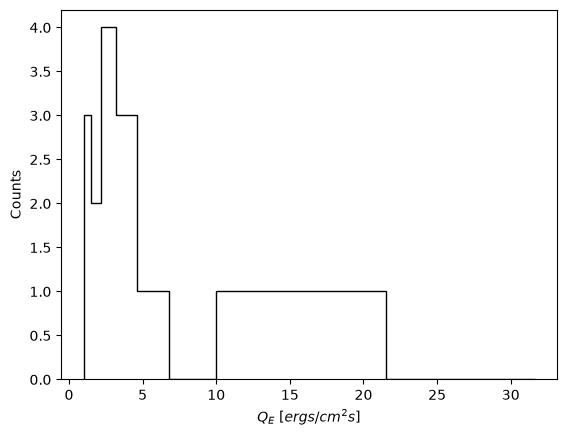

In [10]:
plt.hist(energetic_eflux, bins=np.logspace(0, 1.5, 10), histtype='step', color='k')
plt.xlabel(f'$Q_{{E}}$ [$ergs/cm^2 s$]')
plt.ylabel('Counts');

### Load Christine's data

In [11]:
inversion_dir = elfinasi.data_dir / '20220904_themis_asi_inversion'
header = [
    "date/time", 
    "ELFINLat", 
    "PINALat", 
    "GILLlat", 
    "EFLINLon", 
    "PINALon", 
    "GILLlon", 
    "ClosestStation", 
    "Elevation [deg]",
    "ELFINeflux [erg/cm^2/s]", 
    "ELFINenergy [keV]"
    ]
themis_asi_eflux = pd.read_csv(
    inversion_dir / 'ASIdataCSV0.csv', 
    index_col=0, 
    skiprows=1,  # This is necessary because someone forgot to add ","s to the header!
    names=header,
    parse_dates=True, 
    na_values=('NaN', "-1")
)
themis_asi_eflux = themis_asi_eflux.loc[themis_asi_eflux['Elevation [deg]'] > 10]  # Christine's suggested threshold

In [12]:
themis_asi_eflux.dropna().head()

,ELFINLat,PINALat,GILLlat,EFLINLon,PINALon,GILLlon,ClosestStation,Elevation [deg],ELFINeflux [erg/cm^2/s],ELFINenergy [keV]
date/time,,,,,,,,,,
2022-09-04 04:19:42,58.188570,58.2521,58.1624,272.113669,271.991,272.152,gill,11.5868,0.050685,0.823
2022-09-04 04:19:43,58.123329,58.2521,58.1624,272.097144,271.991,272.152,gill,11.5868,0.050685,0.823
2022-09-04 04:19:44,58.058086,57.9534,58.0769,272.080665,272.228,272.167,gill,11.6890,0.113653,0.857
2022-09-04 04:19:45,57.993499,57.9534,58.0110,272.064065,272.228,272.012,gill,12.0754,0.144092,0.857
2022-09-04 04:19:46,57.927717,57.9534,57.9323,272.047807,272.228,272.046,gill,12.1287,0.191217,0.930


### Combine the ELFIN and THEMIS ASI energy fluxes

Looks good! Now let's merge the ELFIN and THEMIS-ASI $Q$ values on the same time stamps and calculate the percentage contribution of $Q_E$ to the total $Q=Q_E + Q_A$

In [13]:
elfin_eflux = pd.DataFrame(
    {'energetic': energetic_eflux} | {key:val for key, val in zip(pad_obj_eflux.energy, elfin_eflux_ergs.T)}, 
    index=pad_obj_eflux.pad.time
    )
auroral_eflux = pd.DataFrame(
    themis_asi_eflux[['ELFINeflux [erg/cm^2/s]', 'ELFINenergy [keV]']]
    ).rename(columns={'ELFINeflux [erg/cm^2/s]':'q_auroral', 'ELFINenergy [keV]':'e_auroral'})
auroral_eflux.index = auroral_eflux.index.astype("datetime64[ns]")

merged_eflux = pd.merge_asof(
    elfin_eflux, 
    auroral_eflux, 
    left_index=True, 
    right_index=True, 
    direction='nearest', 
    tolerance=pd.Timedelta('1s')
    )
mapped_state.index = mapped_state.index.astype("datetime64[ns]")
merged_eflux = pd.merge_asof(
    merged_eflux, 
    mapped_state, 
    left_index=True, 
    right_index=True, 
    direction='nearest', 
    tolerance=pd.Timedelta('1s')
    )
merged_eflux['energetic_contribution'] = 100*merged_eflux['energetic']/(merged_eflux['q_auroral'] + merged_eflux['energetic'])

In [14]:
merged_eflux

,energetic,63,97,138,183,238,305,385,520,752,...,3728,4906,6500,q_auroral,e_auroral,lat,lon,alt,mlat,energetic_contribution
2022-09-04 04:19:02.375441051,0.003161,0.000443,0.000422,0.000093,0.000041,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.001832,0.000000,NaN,NaN,60.796572,-87.184468,109.999929,69.421828,NaN
2022-09-04 04:19:05.271945883,0.004854,0.001104,0.000530,0.000124,0.000051,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.002753,NaN,NaN,60.601054,-87.240100,109.950716,69.240726,NaN
2022-09-04 04:19:08.137953179,-0.001442,0.000678,0.000365,0.000062,0.000000,0.000013,0.000033,0.0,0.000028,0.000000,...,0.000000,0.000000,-0.002748,NaN,NaN,60.406068,-87.295397,109.525155,69.059514,NaN
2022-09-04 04:19:11.012953243,0.000296,0.000116,0.000064,0.000043,0.000000,0.000000,0.000017,0.0,0.000056,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,60.209899,-87.349784,109.932531,68.878191,NaN
2022-09-04 04:19:13.909442715,0.000895,0.000097,0.000153,0.000000,0.000031,0.000013,0.000017,0.0,0.000028,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,60.014262,-87.403859,109.960464,68.696757,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-04 04:22:44.012952987,-0.003151,0.000116,0.000232,0.000151,0.000286,0.000025,0.000000,0.0,0.000000,-0.000114,...,0.000000,0.000000,-0.003666,NaN,NaN,46.320799,-90.354641,109.976695,55.794603,NaN
2022-09-04 04:22:46.887953051,0.002618,0.000077,0.000049,0.000130,0.000081,0.000063,0.000000,0.0,0.000000,0.000000,...,0.000387,0.001832,0.000000,NaN,NaN,46.125256,-90.388745,109.975523,55.608327,NaN
2022-09-04 04:22:49.784443035,0.001415,0.000039,0.000124,0.000027,0.000153,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,45.929697,-90.422701,109.981642,55.422018,NaN
2022-09-04 04:22:52.650450075,-0.002075,0.000039,0.000108,0.000043,0.000122,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,-0.002451,0.000000,NaN,NaN,45.734126,-90.456501,109.994915,55.235679,NaN


In [15]:
merged_eflux.dropna().describe().round(3)

,energetic,63,97,138,183,238,305,385,520,752,...,3728,4906,6500,q_auroral,e_auroral,lat,lon,alt,mlat,energetic_contribution
count,48.000,48.000,48.000,48.000,48.000,48.000,48.000,48.000,48.000,48.000,...,48.000,48.000,48.000,48.000,48.000,48.000,48.000,48.000,48.000,48.000
mean,1.340,0.067,0.105,0.079,0.158,0.162,0.166,0.165,0.243,0.130,...,0.000,0.000,0.001,7.054,1.842,53.204,-89.004,109.888,62.313,9.090
std,3.338,0.088,0.157,0.126,0.277,0.339,0.415,0.488,0.857,0.543,...,0.001,0.001,0.004,10.350,1.367,3.175,0.673,0.203,2.994,13.850
min,-0.003,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,...,-0.002,-0.002,-0.007,0.051,0.823,48.016,-90.052,109.018,57.407,-1.869
25%,0.003,0.001,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.193,0.930,50.379,-89.608,109.932,59.651,1.484
50%,0.015,0.004,0.003,0.002,0.001,0.001,0.000,0.001,0.001,0.000,...,0.000,0.000,0.000,0.539,0.970,53.721,-88.927,109.963,62.810,4.266
75%,1.019,0.164,0.198,0.135,0.223,0.153,0.087,0.042,0.024,0.010,...,0.000,0.000,0.002,16.367,3.442,55.955,-88.429,109.983,64.909,10.810
max,18.236,0.243,0.558,0.459,1.050,1.431,1.887,2.409,4.787,3.507,...,0.006,0.004,0.014,30.025,4.435,58.123,-87.903,109.996,66.937,68.381


Note: the negative min energetic EFlux is a result of the space-time aliasing, with higher fluxes in the ABLC than the BLC during the ELFIN half-spin period

11-Sep-26 11:24:45: /tmp/ipykernel_1016/479045702.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  bx[2].set_ylim(0, 1E2)



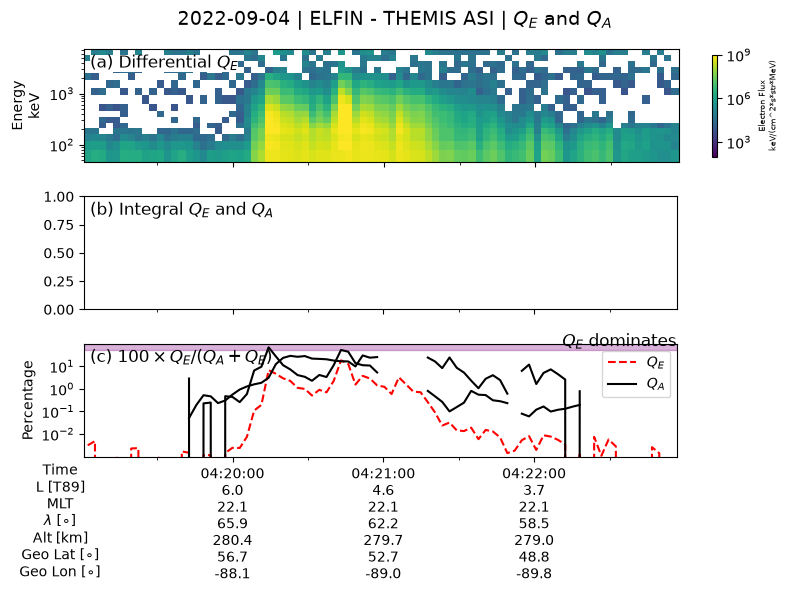

In [16]:
fig, bx = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
pad_obj_eflux.plot_omni(bx[0], labels=True, colorbar=True, vmin=1E2, vmax=1E9, pretty_plot=False, fraction=0.05)
bx[2].plot(
    merged_eflux.index, 
    merged_eflux['energetic'], 
    label=f'$Q_E$', 
    color='r', 
    linestyle='--'
    )
bx[2].plot(
    merged_eflux.index, 
    merged_eflux['q_auroral'], 
    label=f'$Q_A$', color='k'
    )

bx[2].plot(merged_eflux.index, merged_eflux['energetic_contribution'], color='k')
pad_obj_eflux.plot_position(bx[-1])
bx[-1].xaxis.set_major_locator(plt.MaxNLocator(7))
bx[-1].xaxis.set_label_coords(-0.04, -0.007*7)
bx[-1].xaxis.label.set_size(10)

for bx_i in bx[[1, 2]]:
    divider = make_axes_locatable(bx_i)
    cax = divider.append_axes("right", size="10%", pad=0.08)
    cax.remove()

bx[2].set_yscale('log')
bx[2].set_ylabel(f'Energy Flux\n$[ergs/cm^{{2}}s]$')
bx[2].set_yticks([1E-2, 1E-1, 1E0, 1E1])
bx[2].set_ylim(1E-3, 1E2)

bx[2].set_ylabel(f'Percentage')
bx[2].set_ylim(0, 1E2)

labels = (
    f'Differential $Q_E$', 
    f'Integral $Q_E$ and $Q_A$', 
    f'$100 \\times Q_E/(Q_A + Q_E)$'
    )
for i, (ax_i, label, letter) in enumerate(zip(bx, labels, string.ascii_lowercase)):
    _text = ax_i.text(0.01, 0.95, f'({letter}) {label}', transform=ax_i.transAxes, va='top', fontsize=12)
    if i == 0:
        _text.set_bbox(dict(facecolor='white', linewidth=0, pad=0.1, edgecolor='k'))
bx[2].legend()

bx[2].axhspan(50, 100, color='purple', alpha=0.3)
bx[2].text(bx[2].get_xlim()[1], 50, f'$Q_E$ dominates', va='bottom', ha='right', fontsize=12, color='k')

bx[-1].xaxis.set_major_locator(matplotlib.dates.SecondLocator(bysecond=0))
bx[-1].xaxis.set_minor_locator(matplotlib.dates.SecondLocator(bysecond=30))
plt.suptitle(f'{elfin_spectra_time_range[0].date()} | ELFIN - THEMIS ASI | $Q_E$ and $Q_A$', fontsize=14)
plt.tight_layout()

11-Sep-26 11:24:54: /tmp/ipykernel_1016/2670484748.py:98: RuntimeWarning: divide by zero encountered in divide
  pad_obj_eflux.blc.T/pad_obj_eflux.ablc.T,



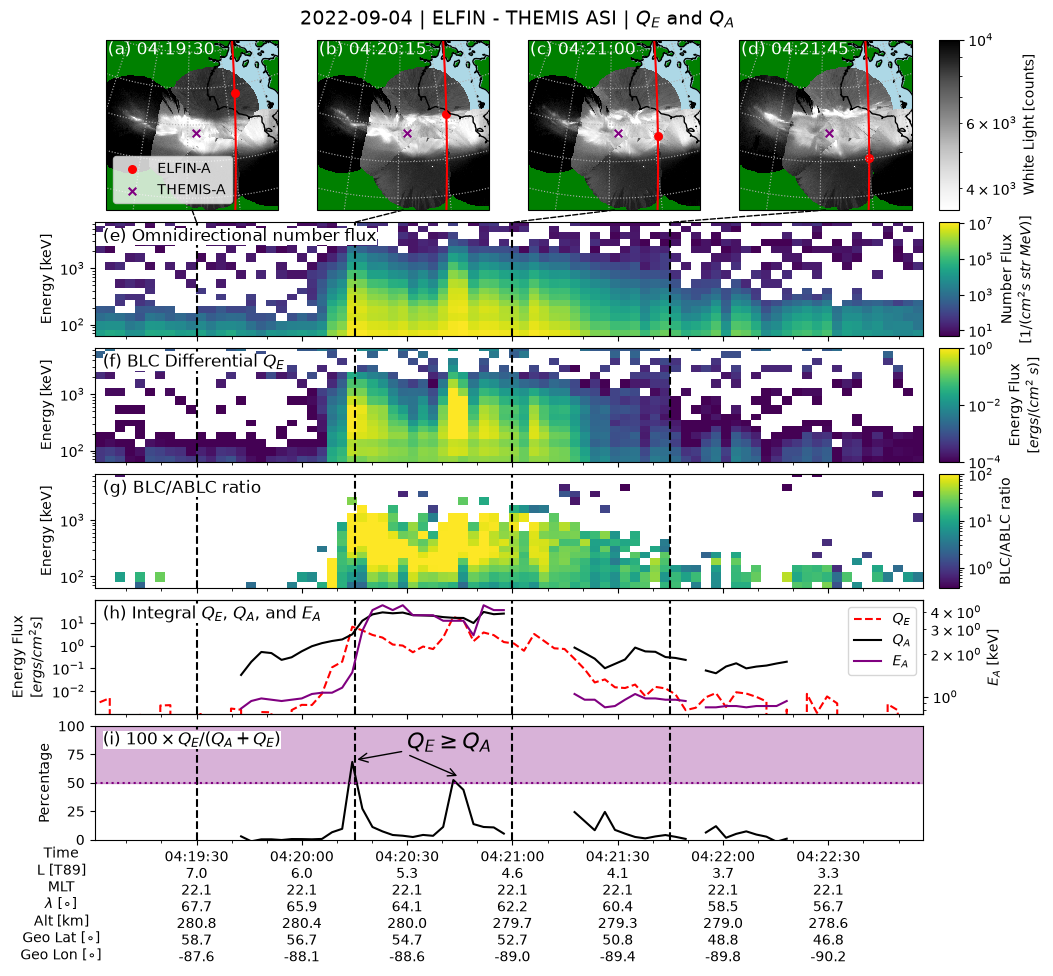

In [17]:
plot_times = [
    datetime(2022, 9, 4, 4, 19, 30),
    datetime(2022, 9, 4, 4, 20, 15),
    datetime(2022, 9, 4, 4, 21, 0),
    datetime(2022, 9, 4, 4, 21, 45),
]
color_bounds = (3500, 10000)

fig = plt.figure(figsize=(9, 10))
gs = fig.add_gridspec(
    6, len(plot_times)+1,
    left=0.03, right=0.99, bottom=0.15, top=0.95,
    wspace=0.1, hspace=0.1,
    height_ratios=(1.5, 1, 1, 1, 1, 1),
    width_ratios=([1]*len(plot_times) + [0.1])
    )

ax = [
    asilib.map.create_map(
        lon_bounds=(-115, -83), 
        lat_bounds=(42, 66), 
        fig_ax=(fig, gs[0, i]),
        ocean_color='lightblue'
        ) for i in range(len(plot_times))
    ]
bx = [None]*(gs.nrows-1)
cbx = [None]*(gs.nrows-1)
for i in range(gs.nrows-1):
    sharex = bx[0] if i > 0 else None
    bx[i] = fig.add_subplot(gs[i+1, :-1], sharex=sharex)

for i in range(4):
    cbx[i] = fig.add_subplot(gs[i, -1],)

for time, ax_i, _label in zip(plot_times, ax, string.ascii_lowercase):
    asis = asilib.Imagers(
        [asilib.asi.themis(location_code=location_code, time=time, alt=alt) 
        for location_code in themis_location_codes]
        )
    asis.plot_map(
        ax=ax_i, 
        min_elevation=5, 
        pcolormesh_kwargs={'rasterized':True}, 
        asi_label=False,
        color_bounds=color_bounds
        )
    ax_i.plot(mapped_state['lon'], mapped_state['lat'], c='r', transform=ccrs.PlateCarree())

    _elfin_loc = ax_i.scatter(
        mapped_state.loc[time, 'lon'], 
        mapped_state.loc[time, 'lat'], 
        c='r', 
        s=30,
        transform=ccrs.PlateCarree(),
        label=f'ELFIN-{elfin_probe.upper()}'
        )
    _themisa_index = themis_mapped_state['a'].index.get_indexer([time], method='nearest')
    _themisa_loc = ax_i.scatter(
        themis_mapped_state['a'].iloc[_themisa_index, :]['lon'], 
        themis_mapped_state['a'].iloc[_themisa_index, :]['lat'], 
        c='purple', 
        s=30,
        marker='x',
        transform=ccrs.PlateCarree(),
        label=f'THEMIS-A',
        zorder=2.01
        )    
    _plot_time = ax_i.text(
        0.01, 0.99, f'({_label}) {time:%H:%M:%S}', va='top', transform=ax_i.transAxes, fontsize=12, c='w'
        )

_legend = ax[0].legend(loc='lower left')

norm = matplotlib.colors.LogNorm(*color_bounds)
colorizer = matplotlib.colorizer.Colorizer(norm=norm, cmap="Greys")
fig.colorbar(matplotlib.colorizer.ColorizingArtist(colorizer),
             cax=cbx[0], label='White Light [counts]')

p, _ = pad_obj_nflux.plot_omni(ax=bx[0], colorbar=False, labels=False, pretty_plot=False)
fig.colorbar(p, label=f'Number Flux\n$[1/(cm^{{2}} s \\ str \\ MeV)]$', cax=cbx[1])

p1 = bx[1].pcolormesh(
    pad_obj_eflux.pad.time, 
    pad_obj_eflux.energy, 
    elfin_eflux_ergs.T,
    shading='nearest',
    norm=matplotlib.colors.LogNorm(vmin=1e-4, vmax=1e0)
    )

assert pad_obj_eflux._flux_units == 'keV/(cm^2*s*str*MeV)', (
    'If we fail here, revisit how elfin_eflux_ergs is calculated. It should be in ergs/cm^2/s.'
    )
fig.colorbar(p1, label=f'Energy Flux\n$[ergs/(cm^2 \\ s)]$', cax=cbx[2])

p2 = bx[2].pcolormesh(
            pad_obj_eflux.pad.time, 
            pad_obj_eflux.energy, 
            pad_obj_eflux.blc.T/pad_obj_eflux.ablc.T,
            shading='nearest',
            norm=matplotlib.colors.LogNorm(vmax=10**2)
            )
bx[0].set(yscale='log', ylim=(pad_obj_eflux.energy[0], pad_obj_eflux.energy[-1]), ylabel='Energy [keV]')
bx[1].set(yscale='log', ylim=(pad_obj_eflux.energy[0], pad_obj_eflux.energy[-1]), ylabel='Energy [keV]')
bx[2].set(yscale='log', ylim=(pad_obj_eflux.energy[0], pad_obj_eflux.energy[-1]), ylabel='Energy [keV]')
fig.colorbar(p2, label='BLC/ABLC ratio', cax=cbx[3])
bx[3].plot(
    merged_eflux.index, 
    merged_eflux['energetic'], 
    label=f'$Q_E$', 
    color='r', 
    linestyle='--'
    )
bx[3].plot(
    merged_eflux.index, 
    merged_eflux['q_auroral'], 
    label=f'$Q_A$', color='k'
    )

bx[4].plot(merged_eflux.index, merged_eflux['energetic_contribution'], color='k')
pad_obj_eflux.plot_position(bx[-1])
bx[-1].xaxis.set_major_locator(plt.MaxNLocator(7))
bx[-1].xaxis.set_label_coords(-0.04, -0.007*7)
bx[-1].xaxis.label.set_size(10)

bx[3].set_yscale('log')
bx[3].set_ylabel(f'Energy Flux\n$[ergs/cm^{{2}}s]$')
bx[3].set_yticks([1E-2, 1E-1, 1E0, 1E1])
bx[3].set_ylim(1E-3, 1E2)
avg_energy_twinx = bx[3].twinx()
avg_energy_twinx.plot(
    merged_eflux.index, 
    merged_eflux['e_auroral'], 
    color='purple',
    label=f'$E_{{A}}$',
    )
avg_energy_twinx.set_ylabel(f'$E_{{A}}$ [keV]')
avg_energy_twinx.set_yscale('log')
# avg_energy_twinx.set_xlim(0.1, 10)

bx[4].set_ylabel(f'Percentage')
bx[4].set_ylim(0, 1E2)

# Connect the subplots and add vertical lines to bx and cx.
for ax_i, image_time_numeric in zip(ax, matplotlib.dates.date2num(plot_times)):
    line = matplotlib.patches.ConnectionPatch(
        xyA=(0.5, 0), coordsA=ax_i.transAxes,
        xyB=(image_time_numeric, bx[0].get_ylim()[1]), coordsB=bx[0].transData, 
        ls='--')
    ax_i.add_artist(line)

    for _other_ax in bx:
        _other_ax.axvline(image_time_numeric, c='k', ls='--', alpha=1)

labels = (
    'Omnidirectional number flux',
    'BLC Differential $Q_E$',
    'BLC/ABLC ratio',
    'Integral $Q_E$, $Q_A$, and $E_A$',
    '$100 \\times Q_E/(Q_A + Q_E)$'
)
for i, (ax_i, label, letter) in enumerate(zip(bx, labels, string.ascii_lowercase[len(plot_times):])):
    _text = ax_i.text(0.01, 0.95, f'({letter}) {label}', transform=ax_i.transAxes, va='top', fontsize=12)
    if i in [0, 1, 2, 3, 4]:
        _text.set_bbox(dict(facecolor='white', linewidth=0, pad=0.1, edgecolor='k'))

lines1, labels1 = bx[3].get_legend_handles_labels()
lines2, labels2 = avg_energy_twinx.get_legend_handles_labels()
bx[3].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

bx[4].axhspan(50, 100, color='purple', alpha=0.3)
bx[4].axhline(50, color='purple', ls=':')
an = bx[4].annotate(
    f'$Q_E \\geq Q_A$', 
    xy=(pd.Timestamp(2022, 9, 4, 4, 20, 15), 70), 
    xytext=(pd.Timestamp(2022, 9, 4, 4, 20, 30), 85), 
    va='center', ha='left', fontsize=16, color='k',
    arrowprops=dict(arrowstyle='->', color='k')
    )
an = bx[4].annotate(
    f'', 
    xy=(pd.Timestamp(2022, 9, 4, 4, 20, 45), 55), 
    xytext=(pd.Timestamp(2022, 9, 4, 4, 20, 30), 75), 
    va='center', ha='left', fontsize=14, color='k',
    arrowprops=dict(arrowstyle='->', color='k')
    )

bx[-1].xaxis.set_major_locator(matplotlib.dates.SecondLocator(bysecond=(0, 30)))
bx[-1].xaxis.set_minor_locator(matplotlib.dates.SecondLocator(bysecond=np.arange(0, 60, 10)))
for bx_i in bx[:-1]:
    bx_i.tick_params(labelbottom=False)
plt.suptitle(f'{elfin_spectra_time_range[0].date()} | ELFIN - THEMIS ASI | $Q_E$ and $Q_A$', fontsize=14)
plt.savefig(elfinasi.plot_dir / f'{elfin_spectra_time_range[0]:%Y%m%d_%H%M%S}_elfin_themis_eflux.pdf', dpi=300, bbox_inches='tight')

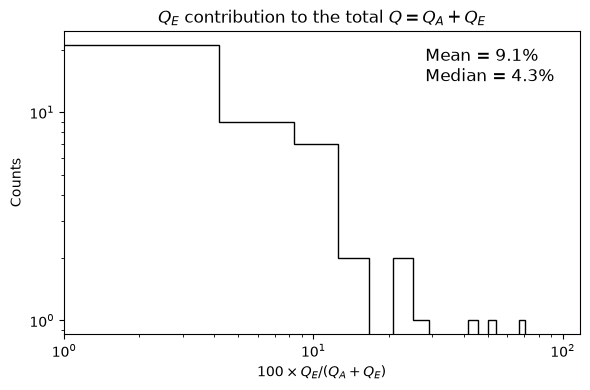

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.hist(merged_eflux['energetic_contribution'], bins=np.linspace(0, 100, 25), histtype='step', color='k')
ax.set_yscale('log')
ax.set_xscale('log')
ax.text(
    0.7, 
    0.95, 
    f'Mean = {merged_eflux["energetic_contribution"].mean():.1f}%\n'
    f'Median = {merged_eflux["energetic_contribution"].median():.1f}%',
    transform=ax.transAxes,
    va='top',
    fontsize=12
    )
ax.set_xlim(1, None)
ax.set(ylabel='Counts', xlabel=f'$100 \\times Q_E/(Q_A + Q_E)$', title=f'$Q_E$ contribution to the total $Q=Q_A + Q_E$');
plt.tight_layout()
plt.savefig(elfinasi.plot_dir / f'{elfin_spectra_time_range[0]:%Y%m%d_%H%M%S}_elfin_themisasi_eflux_contribution.pdf')

# Altitude profile of $Q$ and enhanced ionization

Here we quantify the altitude profile of Q as a function of latitude, and compare and contrast $Q_A$ vs $Q_E$. Here we use `pyGPI5` code to model this, and adapt most of the code from their GitHub tutorial.

In [19]:
AltMinKm = 30.
AltMaxKm = 150.
AltStepKm = 1.0
altkm = np.arange(AltMinKm,AltMaxKm,AltStepKm)

t1970 = datetime(1970,1,1,0,0,0)
tUnix = (elfin_spectra_time_range[0]-t1970).total_seconds()

# Gillam (lat, lon), with -180 < lon < 180 converted to 0 < lon < 360
glat, glon = 56.3472, (-94.707778 + 360)  % 360

ionization = Ionization.Ionization()  # Can use ionization.MaxwellianFlux
chem = Chemistry.Chemistry()
with temporary_silence():
    # Warning! if there are any weird errors, this context manager is going to suppress ALL of them.
    chem.Set_Inital_Ionization(tUnix, glat, glon, AltMinKm, AltMaxKm, AltStepKm);

11-Sep-26 11:25:01: /home/msshumko/research/pyGPI5/pygpi5/Models/IRI2016.py:53: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt = datetime.datetime.utcfromtimestamp(tUnix)#.astimezone(datetime.timezone.utc)

11-Sep-26 11:25:01: /home/msshumko/research/.venv/lib/python3.13/site-packages/scipy/integrate/_ode.py:420: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),

11-Sep-26 11:25:10: /tmp/ipykernel_1016/16027671.py:21: ResourceWarning: unclosed file <_io.TextIOWrapper name='/dev/null' mode='w' encoding='UTF-8'>
  sys.stdout = original_stdout

11-Sep-26 11:25:10: /tmp/ipykernel_1016/16027671.py:22: ResourceWarning: unclosed file <_io.TextIOWrapper name='/dev/null' mode='w' encoding='UTF-8'>
  sys.stderr = original_stderr

In [20]:
_time_range_ib = (datetime(2022, 9, 4, 4, 20, 10), datetime(2022, 9, 4, 4, 20, 25))
energy_channel_idx = np.where((pad_obj_eflux.energy >= 0) & (pad_obj_eflux.energy <= 2_000))[0]
ib_eflux = merged_eflux.loc[_time_range_ib[0]:_time_range_ib[1]].mean()

Let's calculate $I_A$, $I_E$, $Q_A$, $Q_E$, $n_{e,A}$, and $n_{e,E}$ as a function of altitude.

Note: Units of $Q_E$ is $ergs/(cm^2 \ s)$ which are the same as $mW/m^2$

In [21]:
label_box_style = dict(
    boxstyle='square,pad=0.1', 
    facecolor='white',
    alpha=1
)

region_box_style = dict(
    boxstyle='round,pad=0.1', 
    facecolor='white',
    edgecolor='black',
    ls='--',
    lw=0.5,
    alpha=1
)

11-Sep-26 11:45:19: /home/msshumko/research/.venv/lib/python3.13/site-packages/scipy/integrate/_ode.py:420: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),



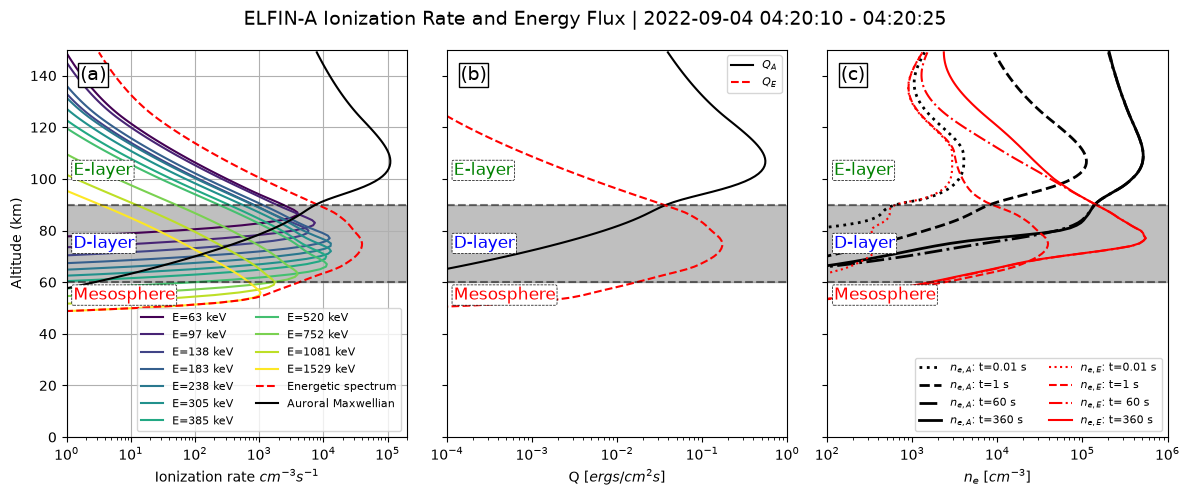

In [69]:
f, gx = plt.subplots(1,3, figsize=(12,5), sharey=True)

EeV = 1000*pad_obj_eflux.energy[energy_channel_idx]
QeV = ib_eflux[pad_obj_eflux.energy[energy_channel_idx]].to_numpy()

color = plt.cm.viridis(np.linspace(0, 1, EeV.shape[0]))

# Pass the Eflux and Energy arrays to the Ionization function to get the ionization rates for each energy channel.
for iEnergy, iQ, iColor in zip(EeV, QeV, color):
    qZ, qZE, qfoo = ionization.Ionization(
        np.array([iEnergy]), np.array([iQ]), AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon
        )
    qZ[qZ<1e-2] = 1e-2
    gx[0].semilogx(qZ, chem.altkm, color=iColor, label=f'E={int(iEnergy/1000)} keV')

# Pass the total Eflux and Energy arrays to the Ionization function to get the combined ionization rates for all energy channels.
qZ, qZE,qfoo = ionization.Ionization(
    EeV, QeV, AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon
    )
qZ[qZ<1e-2] = 1e-2
gx[0].semilogx(qZ, chem.altkm, color='r', ls='--', label=f'Energetic spectrum')

energetic_chem0 = chem(qZ, chem.altkm, IntegrationTime=0.01)
energetic_chem1 = chem(qZ, chem.altkm, IntegrationTime=1)
energetic_chem60 = chem(qZ, chem.altkm, IntegrationTime=60)
energetic_chem360 = chem(qZ, chem.altkm, IntegrationTime=360)

# Now calculate how the energy flux is distributed in altitude. This is done by calculating the energy flux at each altitude and then normalizing it to the total energy flux.
QE_alt = np.zeros_like(chem.altkm)
for iEnergy, iQ in zip(EeV, QeV):
    qZ, qZE, qfoo = ionization.Ionization(
        np.array([iEnergy]), np.array([iQ]), AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon
        )
    total_ionization = np.trapezoid(qZE[0, :], chem.altkm)
    normalized_ionization = qZE[0, :] / total_ionization
    QE_alt += normalized_ionization * iQ

# Now the auroral energies
qZ_aurora, qZE_aurora, qfoo_aurora = ionization.Ionization(
    np.array([1e3*ib_eflux['e_auroral']]), np.array([ib_eflux['q_auroral']]), AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon, IonizationType='Maxwellian'
    )
aurora_chem0 = chem(qZ_aurora, chem.altkm, IntegrationTime=0.01)
aurora_chem1 = chem(qZ_aurora, chem.altkm, IntegrationTime=1)
aurora_chem60 = chem(qZ_aurora, chem.altkm, IntegrationTime=60)
aurora_chem360 = chem(qZ_aurora, chem.altkm, IntegrationTime=360)


gx[0].semilogx(qZ_aurora, chem.altkm, color='k', label=f'Auroral Maxwellian')

total_ionization = np.trapezoid(qZE_aurora[0, :], chem.altkm)
normalized_ionization = qZE_aurora[0, :] / total_ionization
QA_alt = normalized_ionization * ib_eflux['q_auroral']  # Weight by the energy flux of Q_A
gx[1].semilogx(QA_alt, chem.altkm, color='k', label=f'$Q_A$')
gx[1].semilogx(QE_alt, chem.altkm, color='r', ls='--', label=f'$Q_E$')

gx[2].semilogx(aurora_chem0['Ne'], chem.altkm, color='k', ls=':', lw=2, label=f'$n_{{e,A}}$: t=0.01 s')
gx[2].semilogx(aurora_chem1['Ne'], chem.altkm, color='k', ls='--', lw=2, label=f'$n_{{e,A}}$: t=1 s')
gx[2].semilogx(aurora_chem60['Ne'], chem.altkm, color='k', ls='-.', lw=2, label=f'$n_{{e,A}}$: t=60 s')
gx[2].semilogx(aurora_chem360['Ne'], chem.altkm, color='k', lw=2, label=f'$n_{{e,A}}$: t=360 s')

gx[2].semilogx(energetic_chem0['Ne'], chem.altkm, color='r', ls=':', label=f'$n_{{e,E}}$: t=0.01 s')
gx[2].semilogx(energetic_chem1['Ne'], chem.altkm, color='r', ls='--', label=f'$n_{{e,E}}$: t=1 s')
gx[2].semilogx(energetic_chem60['Ne'], chem.altkm, color='r', ls='-.', label=f'$n_{{e,E}}$: t= 60 s')
gx[2].semilogx(energetic_chem360['Ne'], chem.altkm, color='r', label=f'$n_{{e,E}}$: t=360 s')

gx[0].set_xlim([1,2e5])
gx[0].set_ylim([0,150])
gx[0].set_ylabel('Altitude (km)')
# gx[0].set_title('Mono Energetic')
gx[0].set_xlabel(r'Ionization rate $cm^{-3} s^{-1}$')
gx[2].set_xlim(1e2, 1e6)
gx[2].legend(loc='lower right', fontsize=8)
gx[2].set_xlabel(r'$n_e$ [$cm^{-3}$]')
gx[0].grid()
gx[0].legend(loc='lower right', ncols=2, fontsize=8)
gx[1].legend(fontsize=8)
gx[2].legend(loc='lower right', fontsize=8, ncols=2)
gx[1].set_xlim([1e-4,1e0])
gx[1].set_xlabel(r'Q [$ergs/cm^{2} s$]')

trans = lambda ax: transforms.blended_transform_factory(ax.transAxes, ax.transData)

for i, gx_i in enumerate(gx):
    gx_i.axhline(60, color='k', ls='--', alpha=0.5)
    gx_i.axhline(90, color='k', ls='--', alpha=0.5)
    gx_i.axhspan(60, 90, color='k', alpha=0.25)
    gx_i.text(
        0.02, 
        100, 
        f'E-layer', 
        va='bottom', 
        ha='left', 
        fontsize=12, 
        color='green', 
        transform=trans(gx_i),
        bbox=region_box_style
        )
    gx_i.text(
        0.02, 
        75,
        f'D-layer',
        va='center', 
        ha='left', 
        fontsize=12, 
        color='blue', 
        transform=trans(gx_i),
        bbox=region_box_style
        )
    gx_i.text(
        0.02,
        55, 
        f'Mesosphere', 
        va='center', 
        ha='left', 
        fontsize=12,
        transform=trans(gx_i), 
        color='red', 
        bbox=region_box_style
        )
    gx_i.text(
        0.04, 
        0.96, 
        f'({string.ascii_lowercase[i]})', 
        va='top', 
        ha='left', 
        fontsize=14,
        transform=gx_i.transAxes, 
        color='black',
        bbox=label_box_style
        )
plt.suptitle(f'ELFIN-A Ionization Rate and Energy Flux | {_time_range_ib[0]:%Y-%m-%d %H:%M:%S} - {_time_range_ib[1]:%H:%M:%S}', fontsize=14)
plt.tight_layout()
plt.savefig(elfinasi.plot_dir / f'{elfin_spectra_time_range[0]:%Y%m%d_%H%M%S}_elfin_themis_eflux_ionization.pdf')

Check that integrating $Q_E$ for all energy channels gives us the same answer as just running pyGPI5 once.

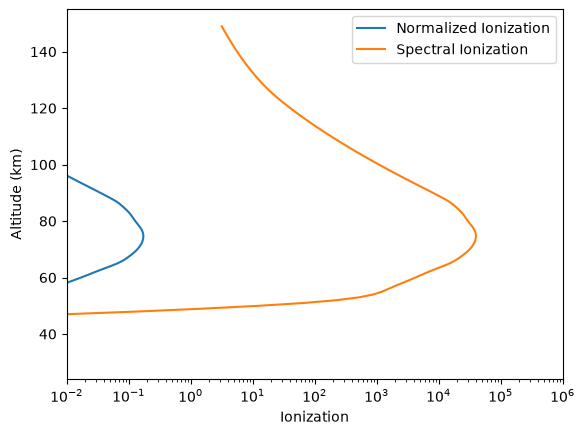

In [23]:
EeV = 1000*pad_obj_eflux.energy[energy_channel_idx]
QeV = ib_eflux[pad_obj_eflux.energy[energy_channel_idx]].to_numpy()

QE_alt = np.zeros_like(chem.altkm)
for iEnergy, iQ in zip(EeV, QeV):
    qZ, qZE, qfoo = ionization.Ionization(np.array([iEnergy]), np.abs([iQ]),AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
    total_ionization = np.trapezoid(qZE[0, :], chem.altkm, dx=AltStepKm)
    normalized_ionization = qZE[0, :] / total_ionization
    QE_alt += normalized_ionization * iQ

qZ, qZE, qfoo = ionization.Ionization(
    EeV, np.abs(QeV), AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon
    )

plt.semilogx(QE_alt, chem.altkm, label='Normalized Ionization')
plt.semilogx(qZE.sum(axis=0), chem.altkm, label='Spectral Ionization')
plt.xlabel('Ionization')
plt.ylabel('Altitude (km)')
plt.xlim([1e-2, 1e6])
plt.legend()

## Now lets' do this as a function of latitude
First we calculate the auroral ionization rate (IA), auroral energy flux (QA), and electron number density from aurora (NA), and then do the same for the energetic  

In [24]:
QE_alt_lat = np.zeros((merged_eflux.shape[0], chem.altkm.shape[0]))
IE_alt_lat = np.zeros((merged_eflux.shape[0], chem.altkm.shape[0]))
NE_alt_lat = np.zeros((merged_eflux.shape[0], chem.altkm.shape[0]))
EeV = 1000*pad_obj_eflux.energy[energy_channel_idx]

for i, (_, row) in enumerate(merged_eflux.iterrows()):
    QeV = row[pad_obj_eflux.energy[energy_channel_idx]].to_numpy().copy()

    # Sometimes the BLC-ABLC fluxes are negative, but this mainly occurs in count starved regions.
    QeV[QeV<0] = 0

    # Pass the total Eflux and Energy arrays to the Ionization function to get the combined ionization rates for all energy channels.
    qZ, qZE, _ = ionization.Ionization(
        EeV, QeV, AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon
        )
    # qZ[qZ<1e-2] = 0
    IE_alt_lat[i, :] = qZ

    # Now sum Q(alt) over multiple ELFIN channels.
    for iEnergy, iQ in zip(EeV, QeV):
        qZ, qZE, _ = ionization.Ionization(
            np.array([iEnergy]), np.array([iQ]), AltMinKm, AltMaxKm, AltStepKm, tUnix, glat, glon
            )
        total_ionization = np.trapezoid(qZE[0, :], chem.altkm)
        normalized_ionization = qZE[0, :] / total_ionization
        QE_alt_lat[i, :] += normalized_ionization * iQ

    chem60 = chem(IE_alt_lat[i, :], chem.altkm, IntegrationTime=60)
    NE_alt_lat[i, :] = chem60['Ne']

QE_alt_lat[IE_alt_lat<1e-2] = np.nan
NE_alt_lat[IE_alt_lat<1e-2] = np.nan
IE_alt_lat[IE_alt_lat<1e-2] = np.nan

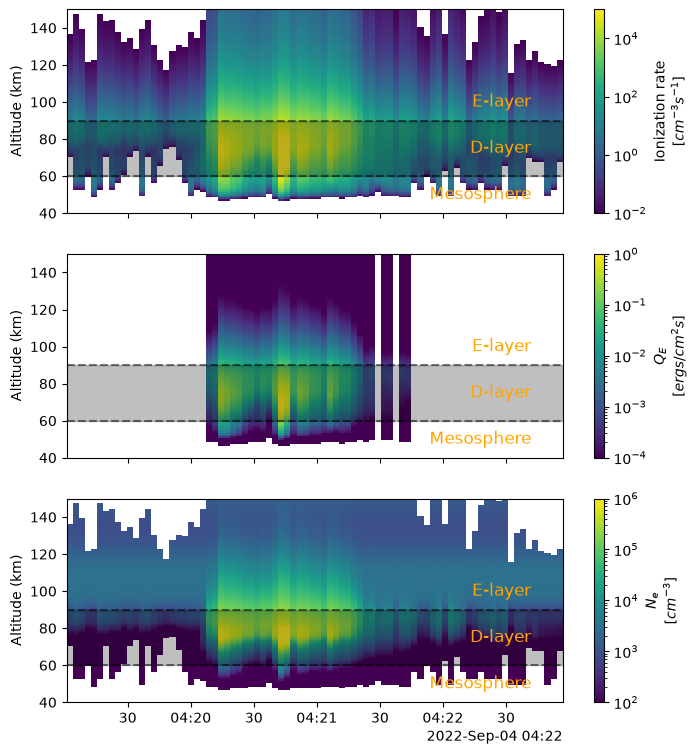

In [25]:
fig, gx = plt.subplots(3, 1, figsize=(8, 9), sharey=True, sharex=True)
p1 = gx[0].pcolormesh(
    merged_eflux.index,
    chem.altkm,
    IE_alt_lat.T,
    norm=matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e5),
)
plt.colorbar(p1, ax=gx[0], label=f'Ionization rate\n[$cm^{{-3}} s^{{-1}}$]')
p2 = gx[1].pcolormesh(
    merged_eflux.index,
    chem.altkm,
    QE_alt_lat.T,
    norm=matplotlib.colors.LogNorm(vmin=1e-4, vmax=10e-1),
)
plt.colorbar(p2, ax=gx[1], label=f'$Q_E$\n[$ergs/cm^{{2}} s$]');

p3 = gx[2].pcolormesh(
    merged_eflux.index,
    chem.altkm,
    NE_alt_lat.T,
    norm=matplotlib.colors.LogNorm(vmin=1e2, vmax=1e6),
)
plt.colorbar(p3, ax=gx[2], label=f'$N_e$\n[$cm^{{-3}}$]');

for gx_i in gx:
    gx_i.set_ylabel('Altitude (km)')
    gx_i.set_ylim([40, 150])
    gx_i.tick_params(labelbottom=False)

    gx_i.axhline(60, color='k', ls='--', alpha=0.5)
    gx_i.axhline(90, color='k', ls='--', alpha=0.5)
    gx_i.axhspan(60, 90, color='k', alpha=0.25)
    gx_i.text(
        gx_i.get_xlim()[1]-15/86400, 100, f'E-layer', va='center', ha='right', fontsize=12, color='orange'
        )
    gx_i.text(
        gx_i.get_xlim()[1]-15/86400, 75, f'D-layer', va='center', ha='right', fontsize=12, color='orange'
        )
    gx_i.text(
        gx_i.get_xlim()[1]-15/86400, 50, f'Mesosphere', va='center', ha='right', fontsize=12, color='orange'
        )
    # gx_i.axhspan(gx_i.get_ylim()[0], 60, color='purple', alpha=0.1)
gx[-1].tick_params(labelbottom=True)
plt.savefig(elfinasi.plot_dir / f'{elfin_spectra_time_range[0]:%Y%m%d_%H%M%S}_elfin_eflux_ionization_altitude.pdf')

Now let's compare the auroral ionization rate (IA), auroral energy flux (QA), and electron number density from aurora (NA), with their energetic counterparts (IE, QE, and NE)

In [26]:
QA_alt_lat = np.nan*np.zeros((merged_eflux.shape[0], chem.altkm.shape[0]))
IA_alt_lat = np.nan*np.zeros((merged_eflux.shape[0], chem.altkm.shape[0]))
NA_alt_lat = np.nan*np.zeros((merged_eflux.shape[0], chem.altkm.shape[0]))
EeV_elfin = 1e3*pad_obj_eflux.energy[energy_channel_idx]

for i, (_, row) in enumerate(merged_eflux.iterrows()):
    # QeV_elfin = row[pad_obj_eflux.energy[energy_channel_idx]].to_numpy()
    _glat, _glon = row['lat'], (row['lon'] + 360)  % 360

    # Pass the total Eflux and Energy arrays to the Ionization function to get the combined ionization rates for all energy channels.
        # qZ_elfin, qZE_elfin, _ = ionization.Ionization(
        #     EeV_elfin, QeV_elfin, AltMinKm, AltMaxKm, AltStepKm, tUnix, _glat, _glon
        #     )
    qZ_aurora, qZE_aurora, qfoo_aurora = ionization.Ionization(
        np.array([1e3*row['e_auroral']]),
        np.array([row['q_auroral']]),
        AltMinKm,
        AltMaxKm,
        AltStepKm,
        tUnix,
        _glat,
        _glon,
        IonizationType='Maxwellian'
    )
    
    IA_alt_lat[i, :] = qZ_aurora
    total_ionization = np.trapezoid(qZE_aurora[0, :], chem.altkm)
    normalized_ionization = qZE_aurora[0, :] / total_ionization
    QA_alt_lat[i, :] = normalized_ionization * row['q_auroral']  # Weight by the energy flux of Q_A

    chem60 = chem(IA_alt_lat[i, :], chem.altkm, IntegrationTime=60)
    NA_alt_lat[i, :] = chem60['Ne']

QA_alt_lat[IA_alt_lat<1e-2] = np.nan
NA_alt_lat[IA_alt_lat<1e-2] = np.nan
IA_alt_lat[IA_alt_lat<1e-2] = np.nan

11-Sep-26 11:26:15: /home/msshumko/research/.venv/lib/python3.13/site-packages/scipy/integrate/_ode.py:420: UserWarning: vode: Repeated convergence failures. (Perhaps bad Jacobian supplied or wrong choice of MF or tolerances.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),



In [27]:
prgn_gray_colors = ["#762a83", "#7e7e7e", "#1b7837"]

# 2. Create the custom continuous colormap
custom_prgn = matplotlib.colors.LinearSegmentedColormap.from_list("PRGn_Gray", prgn_gray_colors)

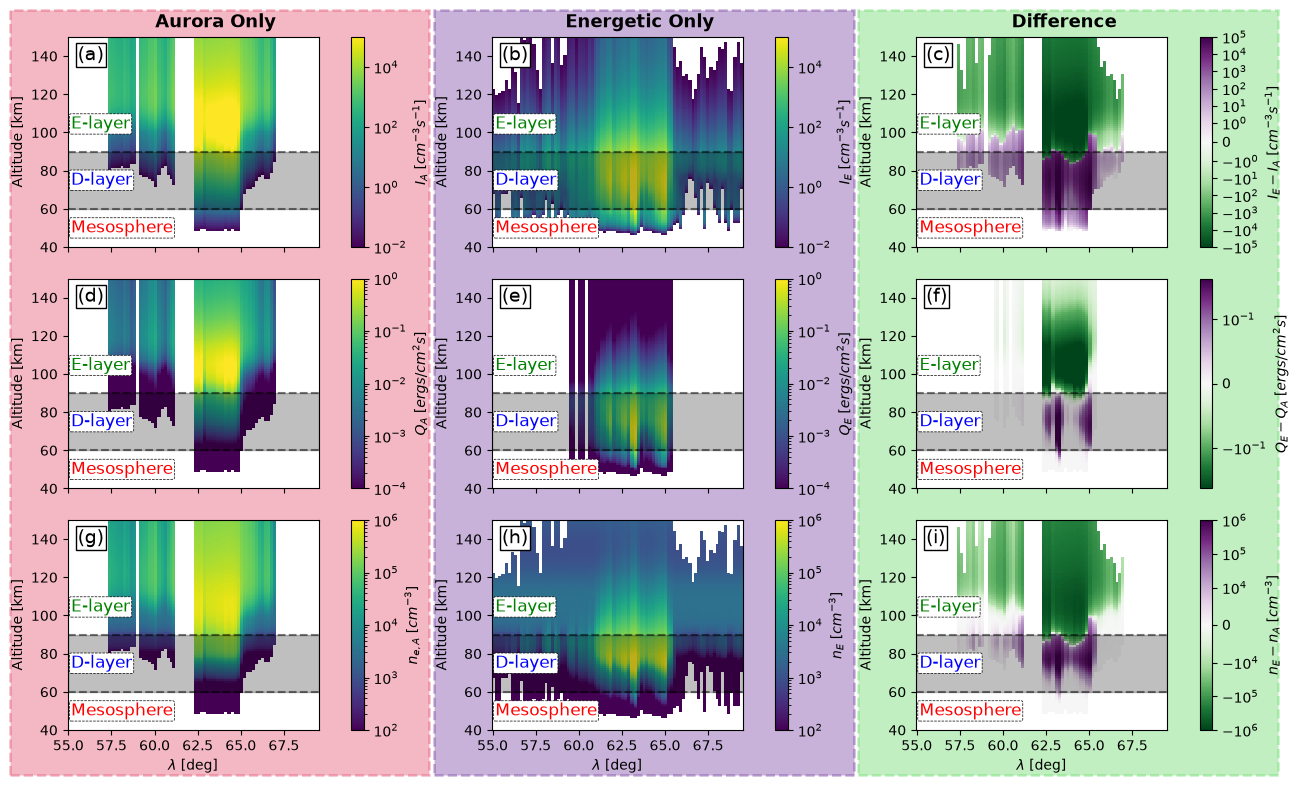

In [54]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(
    3, 9,
    width_ratios=(20, 1, 5, 20, 1, 5, 20, 1, 5),
    height_ratios=(1, 1, 1),
    wspace=0.3,
    hspace=0.15,
)
hx = np.empty((3, gs.ncols), dtype=object)

_delta_I = IE_alt_lat - IA_alt_lat
_delta_Q = QE_alt_lat - QA_alt_lat
_delta_ne = NE_alt_lat - NA_alt_lat

for row in range(3):
    for col in range(gs.ncols):
        if col in (3, 6):
            hx[row, col] = fig.add_subplot(gs[row, col], sharex=hx[row, 0], sharey=hx[row, 0])
        elif col in (2, 5, 8):
            pass
        else:
            hx[row, col] = fig.add_subplot(gs[row, col])


ionization_norm = matplotlib.colors.LogNorm(vmin=1e-2, vmax=1e5)
q_norm = matplotlib.colors.LogNorm(vmin=1e-4, vmax=1e0)
Ne_norm = matplotlib.colors.LogNorm(vmin=1e2, vmax=1e6)

p1 = hx[0, 0].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    IA_alt_lat.T,
    norm=ionization_norm,
)
fig.colorbar(p1, cax=hx[0, 1], label=f'$I_A$ [$cm^{{-3}} s^{{-1}}$]')
p2 = hx[1, 0].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    QA_alt_lat.T,
    norm=q_norm,
)
fig.colorbar(p2, cax=hx[1, 1], label=f'$Q_A$ [$ergs/cm^{{2}} s$]')
p3 = hx[2, 0].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    NA_alt_lat.T,
    norm=Ne_norm,
)
fig.colorbar(p3, cax=hx[2, 1], label=f'$n_{{e, A}}$ [$cm^{{-3}}$]')

p4 = hx[0, 3].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    IE_alt_lat.T,
    norm=ionization_norm,
)
fig.colorbar(p4, cax=hx[0, 4], label=f'$I_E$ [$cm^{{-3}} s^{{-1}}$]')
p5 = hx[1, 3].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    QE_alt_lat.T,
    norm=q_norm,
)
fig.colorbar(p5, cax=hx[1, 4], label=f'$Q_E$ [$ergs/cm^{{2}} s$]')
p6 = hx[2, 3].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    NE_alt_lat.T,
    norm=Ne_norm,
)
fig.colorbar(p6, cax=hx[2, 4], label=f'$n_E$ [$cm^{{-3}}$]')

p7 = hx[0, 6].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    _delta_I.T,
    cmap='PRGn_r',
    norm=matplotlib.colors.SymLogNorm(linthresh=1e0, vmin=-1e5, vmax=1e5)
)
fig.colorbar(p7, cax=hx[0, 7], label=f'$I_E-I_A$ [$cm^{{-3}} s^{{-1}}$]')
p8 = hx[1, 6].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    _delta_Q.T,
    cmap='PRGn_r',
    norm=matplotlib.colors.SymLogNorm(linthresh=0.1, vmin=-0.5, vmax=0.5),
)
fig.colorbar(p8, cax=hx[1, 7], label=f'$Q_E-Q_A$ [$ergs/cm^{{2}} s$]')
p9 = hx[2, 6].pcolormesh(
    merged_eflux['mlat'],
    chem.altkm,
    _delta_ne.T,
    cmap='PRGn_r',
    norm=matplotlib.colors.SymLogNorm(linthresh=1e4, vmin=-1e6, vmax=1e6),
)
fig.colorbar(p9, cax=hx[2, 7], label=f'$n_E-n_A$ [$cm^{{-3}}$]')

for row in range(3):
    for col in (0, 3, 6):
        hx[row, col].set_ylabel('Altitude [km]')

        hx[row, col].set_ylim([40, 150])
        hx[row, col].tick_params(labelbottom=False)

        hx[row, col].axhline(60, color='k', ls='--', alpha=0.5)
        hx[row, col].axhline(90, color='k', ls='--', alpha=0.5)
        hx[row, col].axhspan(60, 90, color='k', alpha=0.25)
        hx[row, col].text(
            hx[row, col].get_xlim()[0] + 0.2, 100, f'E-layer', va='bottom', ha='left', fontsize=12, color='green', bbox=region_box_style
            )
        hx[row, col].text(
            hx[row, col].get_xlim()[0] + 0.2, 75, f'D-layer', va='center', ha='left', fontsize=12, color='blue', bbox=region_box_style
            )
        hx[row, col].text(
            hx[row, col].get_xlim()[0] + 0.2, 50, f'Mesosphere', va='center', ha='left', fontsize=12, color='red', bbox=region_box_style
            )
        hx[row, col].text(
            0.04, 
            0.96, 
            f'({string.ascii_lowercase[3*row+col//3]})', 
            va='top', 
            ha='left', 
            fontsize=14, 
            color='black',
            transform=hx[row, col].transAxes,
            bbox=label_box_style
            )

for gx_i in hx[-1, [0, 3, 6]]:
    gx_i.tick_params(labelbottom=True)
    gx_i.set_xlabel(f'$\\lambda$ [deg]')

# Draw column-group boxes and titles using figure coordinates.
group_specs = [
    ((0, 1), 'Aurora Only', 'crimson'),
    ((3, 4), 'Energetic Only', 'indigo'),
    ((6, 7), 'Difference', 'limegreen'),
]
for cols, label, color in group_specs:
    group_axes = [hx[r, c] for r in range(3) for c in cols]
    x0 = min(ax.get_position().x0 for ax in group_axes)
    y0 = min(ax.get_position().y0 for ax in group_axes)
    x1 = max(ax.get_position().x1 for ax in group_axes)
    y1 = max(ax.get_position().y1 for ax in group_axes)

    pad_x = 0.006
    pad_y = 0.05
    title_gap = 0.00
    title_band = -0.02
    left_extra = 0.030
    right_extra = 0.035

    rect = matplotlib.patches.Rectangle(
        (x0 - pad_x - left_extra, y0 - pad_y),
        (x1 - x0) + 2 * pad_x + left_extra + right_extra,
        (y1 - y0) + 2 * pad_y + title_gap + title_band,
        transform=fig.transFigure,
        fill=True,
        lw=1.8,
        ls='--',
        ec=color,
        fc=color,
        zorder=0,
        alpha=0.3
    )
    fig.add_artist(rect)

    fig.text(
        (x0 + x1) / 2,
        y1 + 0.006,
        label,
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
    )
plt.savefig(elfinasi.plot_dir / f'{elfin_spectra_time_range[0]:%Y%m%d_%H%M%S}_elfin_themis_asi_compare_iz_qz_nez.pdf')

In [29]:
np.nanquantile(_delta_Q, [0.025, 0.5, 0.975])

array([-0.97779268, -0.01230941,  0.23935635])

## Load and analyze THEMIS probe spectra

In [30]:
themis_time_range = ('2022-09-04T03:50', '2022-09-04T04:50')
_themis_time_range = [dateutil.parser.parse(t_i) for t_i in themis_time_range]
coordinates = 'gsm'

themis_a_spectra_time_ranges = (
    [datetime(2022, 9, 4, 4, 12, 0), datetime(2022, 9, 4, 4, 14, 0)],
    [datetime(2022, 9, 4, 4, 25, 0), datetime(2022, 9, 4, 4, 30, 0)],
)
themis_d_spectra_time_ranges = (
    [datetime(2022, 9, 4, 4, 16, 0), datetime(2022, 9, 4, 4, 19, 0)],
    [datetime(2022, 9, 4, 4, 23, 0), datetime(2022, 9, 4, 4, 25, 0)],
)
themis_colors = plt.cm.viridis(np.linspace(0, 1, len(themis_a_spectra_time_ranges)))

In [31]:
themis_probes = np.array(['a', 'd', 'e'])
Ew_key = {'a':'fff_32_edc34', 'd':'fff_32_edc34', 'e':'fff_32_edc12'}
Bw_key = {'a':'fff_32_scm3', 'd':'fff_32_scm3', 'e':'fff_32_scm3'}

In [32]:
no_update = False

pyspedas.themis.fgm(probe='a', trange=themis_time_range, time_clip=True, no_update=no_update)
pyspedas.themis.sst(probe='a', trange=themis_time_range, time_clip=True, no_update=no_update)
pyspedas.themis.mom(probe='a', trange=themis_time_range, time_clip=True, no_update=no_update)
pyspedas.themis.fft(probe='a', trange=themis_time_range, time_clip=True, no_update=no_update)
pyspedas.themis.state(probe='a', trange=themis_time_range, time_clip=True, no_update=no_update)

tha_fgm_xr = pytplot.get_data(f'tha_fgl_{coordinates}')
tha_fgm_times = np.array([t_i.replace(tzinfo=None) for t_i in pyspedas.time_datetime(tha_fgm_xr.times)])
tha_vi_xr = pytplot.get_data(f'tha_peim_velocity_{coordinates}')
tha_sst_xr = pytplot.get_data(f'tha_psef_en_eflux')
tha_sst_xr_metadata = pytplot.get_data(f'tha_psef_en_eflux', metadata=True)
sst_flux_units = tha_sst_xr_metadata['CDF']['VATT']['UNITS'].split()[0]
valid_sst_channels = np.where(~np.isnan(tha_sst_xr.v[0, :]))[0]
tha_sst_times = np.array([t_i.replace(tzinfo=None) for t_i in pyspedas.time_datetime(tha_sst_xr.times)])
tha_sst_spectrum = 1E3*tha_sst_xr.y[:, valid_sst_channels]/tha_sst_xr.v[0, valid_sst_channels]
tha_bw_xr = pytplot.get_data(f'tha_{Bw_key['a']}')
tha_ew_xr = pytplot.get_data(f'tha_{Ew_key['a']}')

print(f'{sst_flux_units=}')

sst_flux_units='eV/(cm^2-s-sr-eV)'


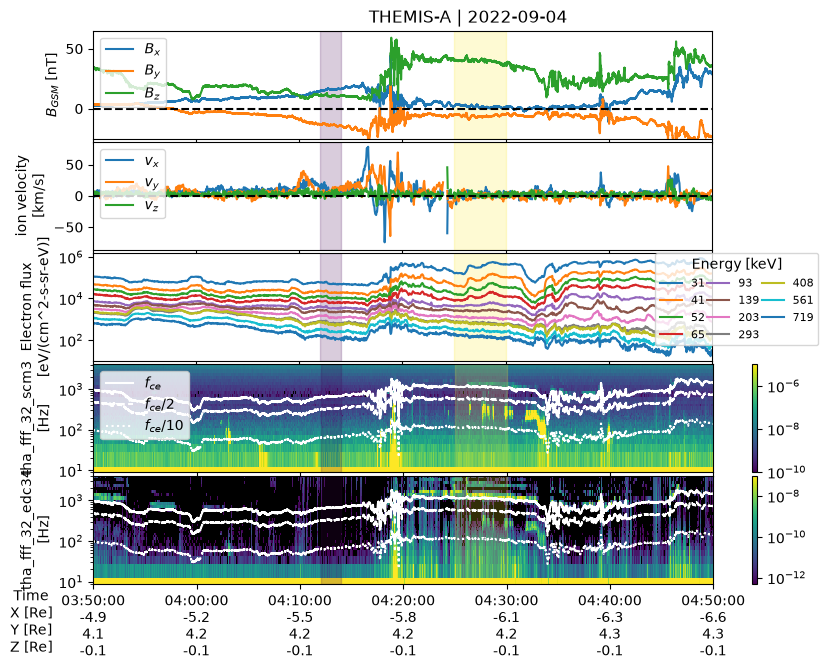

In [33]:
fig, ax = plt.subplots(5, sharex=True, figsize=(10, 7))

_lines = ax[0].plot(tha_fgm_times, tha_fgm_xr.y)
ax[0].legend(iter(_lines), [f'$B_{{{i}}}$' for i in ['x', 'y', 'z']], loc='upper left')
ax[0].axhline(0, c='k', ls='--')
ax[0].set(
    ylim=(-25, 1.1*np.max(tha_fgm_xr.y)), 
    ylabel=f'$B_{{{coordinates.upper()}}}$ [nT]',
    xlim=_themis_time_range
    )

_lines = ax[1].plot(pyspedas.time_datetime(tha_vi_xr.times), tha_vi_xr.y)
ax[1].legend(iter(_lines), [f'$v_{{{i}}}$' for i in [f'x', 'y', 'z']], loc='upper left')
ax[1].axhline(0, c='k', ls='--')
ax[1].set(ylim=(-1.1*np.nanmax(tha_vi_xr.y), 1.1*np.nanmax(tha_vi_xr.y)), ylabel='ion velocity\n[km/s]')

for valid_e_channel in valid_sst_channels:
    ax[2].plot(
        tha_sst_times, 
        tha_sst_spectrum[:, valid_e_channel], 
        label=int(tha_sst_xr.v[0, valid_e_channel]/1000)
        )
ax[2].set(yscale='log', ylabel=f'Electron flux\n[{sst_flux_units}]')
ax[2].legend(fontsize=8, ncols=3, title='Energy [keV]', loc='upper left', bbox_to_anchor=(0.9, 1.05), columnspacing=0.2)

p = ax[3].pcolormesh(
    np.array(pyspedas.time_datetime(tha_bw_xr.times)), 
    tha_bw_xr.v, 
    tha_bw_xr.y.T, 
    norm=matplotlib.colors.LogNorm(vmax=1E-5),
    shading='nearest'
    )
plt.colorbar(p, ax=ax[3])
ax[3].set(yscale='log', ylabel=f'tha_{Bw_key['a']}\n[Hz]')    
f_ce = np.abs(ELECTRON_CHARGE)*1E-9*np.linalg.norm(tha_fgm_xr.y, axis=1)/(2*np.pi*ELECTRON_MASS)

p = ax[4].pcolormesh(
    pyspedas.time_datetime(tha_ew_xr.times), 
    tha_ew_xr.v, 
    tha_ew_xr.y.T, 
    norm=matplotlib.colors.LogNorm(vmax=1E-7)
    )
plt.colorbar(p, ax=ax[4])
ax[4].set(yscale='log', ylabel=f'tha_{Ew_key['a']}\n[Hz]')

for ax_i in ax[3:]:
    ax_i.plot(pyspedas.time_datetime(tha_fgm_xr.times), f_ce, label=f'$f_{{ce}}$', c='w', ls='-')
    ax_i.plot(pyspedas.time_datetime(tha_fgm_xr.times), f_ce/2, label=f'$f_{{ce}}/2$', c='w', ls='--')
    ax_i.plot(pyspedas.time_datetime(tha_fgm_xr.times), f_ce/10, label=f'$f_{{ce}}/10$', c='w', ls=':')
    ax_i.set_facecolor('k')
ax[3].legend(loc='upper left')

plt.suptitle(f'THEMIS-A | {themis_time_range[0][:10]}')

state_xr = pytplot.get_data(f'tha_pos_{coordinates}')
state_times = pyspedas.time_datetime(state_xr.times)
state_times = [state_time.replace(tzinfo=None) for state_time in state_times]
state_df = pd.DataFrame(
    index=state_times,
    data={f'{component.upper()} [Re]':state_xr.y[:, i]/R_E for i, component in enumerate(['x', 'y', 'z'])}
    )
manylabels.ManyLabels(ax[-1], state_df)

for ax_i in ax[:3]:
    divider = make_axes_locatable(ax_i)
    cax = divider.append_axes("right", size="24%", pad=0.08)
    cax.remove()
plt.subplots_adjust(hspace=0.03, top=0.95)

for themis_spectra_time_range, color in zip(themis_a_spectra_time_ranges, themis_colors):
    for ax_i in ax:
        ax_i.axvspan(*themis_spectra_time_range, color=color, alpha=0.2)
plt.savefig(elfinasi.plot_dir / f'{matplotlib.dates.num2date(ax[0].get_xlim()[0]):%Y%m%d_%H%M}_themisa_summary.pdf')

What fraction of the total field was Bz before and after the dipolarization?

In [34]:
for i, themis_time_range in enumerate(themis_a_spectra_time_ranges):
    idx = np.where((np.array(tha_fgm_times)>=themis_time_range[0]) & (np.array(tha_fgm_times)<=themis_time_range[1]))[0]
    mean_b = tha_fgm_xr.y[idx, :].mean(axis=0)
    mean_bxy = tha_fgm_xr.y[idx, 1:].mean(axis=0)
    
    print(
        f'{themis_time_range=}\n|B| = {np.linalg.norm(mean_b) :.2f} nT,'
        f'|Bz|/|B| = {mean_b[-1]/np.linalg.norm(mean_b) :.2f}, '
        f'|Bz|/|Bxy| = {mean_b[-1]/np.linalg.norm(mean_bxy) :.2f}\n'
        )

themis_time_range=[datetime.datetime(2022, 9, 4, 4, 12), datetime.datetime(2022, 9, 4, 4, 14)]
|B| = 23.59 nT,|Bz|/|B| = 0.46, |Bz|/|Bxy| = 0.62

themis_time_range=[datetime.datetime(2022, 9, 4, 4, 25), datetime.datetime(2022, 9, 4, 4, 30)]
|B| = 40.28 nT,|Bz|/|B| = 0.99, |Bz|/|Bxy| = 0.99



# Calc THEMIS Spectra

In [35]:
tha_fgm_times = np.array([t_i.replace(tzinfo=None) for t_i in pyspedas.time_datetime(tha_fgm_xr.times)])
bidx_before = np.where(
    (tha_fgm_times>=themis_a_spectra_time_ranges[0][0]) & 
    (tha_fgm_times<=themis_a_spectra_time_ranges[0][1])
    )[0]
bidx_after = np.where(
    (tha_fgm_times>=themis_a_spectra_time_ranges[-1][0]) & 
    (tha_fgm_times<=themis_a_spectra_time_ranges[-1][1])
    )[0]
mag_b = np.linalg.norm(tha_fgm_xr.y, axis=1)
mean_b_before = mag_b[bidx_before].mean()
mean_b_after = mag_b[bidx_after].mean()
print(f'B field before: {mean_b_before:.2f} nT and after: {mean_b_after:.2f} nT.')

B field before: 23.60 nT and after: 40.31 nT.


In [36]:
themis_spectra_mean = np.full((len(themis_a_spectra_time_ranges), len(tha_sst_xr.v[0, valid_sst_channels])), np.nan)
themis_spectra_iqr = np.full((len(themis_a_spectra_time_ranges), 2, len(tha_sst_xr.v[0, valid_sst_channels])), np.nan)
for i, themis_spectra_time_range in enumerate(themis_a_spectra_time_ranges):
    idx = np.where(
        (tha_sst_times>=themis_spectra_time_range[0]) & 
        (tha_sst_times<=themis_spectra_time_range[1])
        )[0]
    themis_spectra_mean[i, :] = np.mean(tha_sst_spectrum[idx, :], axis=0)
    themis_spectra_iqr[i, ...] = np.quantile(tha_sst_spectrum[idx, :], (0.25, 0.75), axis=0)

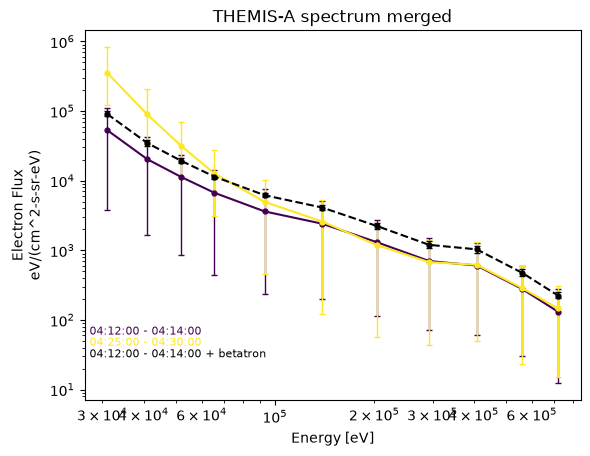

In [37]:
fig, ax = plt.subplots()
for i, (themis_time_range, color) in enumerate(zip(themis_a_spectra_time_ranges, themis_colors)):
    ax.errorbar(tha_sst_xr.v[0, valid_sst_channels],  themis_spectra_mean[i, :], color=color, yerr=themis_spectra_iqr[i, ...], capsize=2,
            markersize=7, elinewidth=1, marker='.', ls='-')
    ax.text(
        0.01, 0.2-0.03*i, f'{themis_time_range[0]:%H:%M:%S} - {themis_time_range[1]:%H:%M:%S}', 
        fontsize=8, transform=ax.transAxes, va='top', ha='left', color=color
        )
    
ax.errorbar(
    tha_sst_xr.v[0, valid_sst_channels],  
    (mean_b_after/mean_b_before)*themis_spectra_mean[0, :], 
    color='k', 
    yerr=(mean_b_after/mean_b_before)*np.abs(themis_spectra_mean[0, :]-themis_spectra_iqr[0, :]), 
    capsize=2,
    markersize=7, 
    elinewidth=1, 
    marker='.', 
    ls='--'
    )
ax.text(
        0.01, 0.2-0.03*(i+1), f'{themis_a_spectra_time_ranges[0][0]:%H:%M:%S} - {themis_a_spectra_time_ranges[0][1]:%H:%M:%S} + betatron', 
        fontsize=8, transform=ax.transAxes, va='top', ha='left', color='k'
        )

ax.set(xlabel='Energy [eV]', yscale='log', xscale='log', title='THEMIS-A spectrum merged')
ax.set_ylabel(f'Electron Flux\n{sst_flux_units}');

So it looks like betatron acceleration does not explain the increase in the fluxes. This seems like an injection!

# Compare ELFIN and THEMIS spectra

Are there times when the two spectra agree?

In [38]:
elfin_fit_idx = np.where((pad_obj_nflux.energy>=integrate_energies_kev[0]) & (pad_obj_nflux.energy<=integrate_energies_kev[-1]))[0]
themis_fit_idx = np.where((tha_sst_xr.v[0, :]>=1e3*integrate_energies_kev[0]) & (tha_sst_xr.v[0, :]<=1e3*integrate_energies_kev[-1]) & (~np.isnan(tha_sst_xr.v[0, :])))[0]

In [39]:
def fit_exponent(x_data, y_data):
    """
    Fits an exponent function of the form y = j0*exp(-E/E0)

    Parameters
    ----------
    x_data: np.array
        The independent variable
    y_data: np.array
        The dependent variable
    
    Returns
    -------
    E0, J0: float
        The J0 and E0 parameters
    """
    with np.errstate(divide='ignore'):
        valid_logy = np.isfinite(np.log(y_data))
    if np.sum(valid_logy) < 2:
        warnings.warn(f'{np.sum(valid_logy)} (<2) valid log(y) points to fit to an exponential: {y_data.values=}.')
        return np.nan, np.nan
    slope, intercept, _, _, _ = scipy.stats.linregress(x_data[valid_logy], np.log(y_data[valid_logy]))
    return -1/slope, np.exp(intercept)

def fit_powerlaw(x_data, y_data):
    """
    Fits a power law function of the form y = j0*E^-gamma

    Parameters
    ----------
    x_data: np.array
        The independent variable
    y_data: np.array
        The dependent variable
    
    Returns
    -------
    gamma, j0: float
        The spectral slope (gamma) and j0 parameters
    """
    with np.errstate(divide='ignore'):
        valid_logy = np.isfinite(np.log(y_data))
    if np.sum(valid_logy) < 2:
        warnings.warn(f'{np.sum(valid_logy)} (<2) valid log(y) points to fit to a powelaw: {y_data.values=}.')
        return np.nan, np.nan
    gamma, intercept, _, _, _ = scipy.stats.linregress(np.log(x_data)[valid_logy], np.log(y_data[valid_logy]))
    return -gamma, np.exp(intercept)

def fit_elfin_spectrum(pad_obj, time_range, energy_range=(50, 200), spectral_type='exp', pa='blc-ablc'):
    time_idx = np.where((pad_obj.pad.time >= time_range[0]) & (pad_obj.pad.time <= time_range[1]))[0]
    energy_channel_idx = np.where((pad_obj.energy >= energy_range[0]) & (pad_obj.energy <= energy_range[1]))[0]

    if pa == 'blc-ablc':
        _flux_timeseries = (pad_obj.blc-pad_obj.ablc)[time_idx][:, energy_channel_idx]
        _spectrum = np.mean(_flux_timeseries, axis=0)
    elif pa == 'omni':
        omni_fluxes = pad_obj.pad.mean(dim='pa')
        _spectrum = np.mean(omni_fluxes[time_idx, :][:, energy_channel_idx], axis=0)
    else:
        raise NotImplementedError(
            f'Unknown pa: {pa}. Can only fit a "blc-ablc" or "omni" spectrum.'
            )
    _spectrum /= 1e3 # Convert from #/(cm^2 sr s MeV) to #/(cm^2 sr s keV)
    if spectral_type == 'exp':
        return fit_exponent(pad_obj.energy[energy_channel_idx], _spectrum)
    elif spectral_type == 'powerlaw':
        return fit_powerlaw(pad_obj.energy[energy_channel_idx], _spectrum)
    else:
        raise NotImplementedError(
            f'Unknown spectral_type: {spectral_type}. Can only fit an "exponential", "powerlaw", or "exp_powerlaw".'
            )
    
def fit_themis_spectrum(_sst, time_range, energy_range=(50, 200), spectral_type='exp'):
    sst_times = np.array([t_i.replace(tzinfo=None) for t_i in pyspedas.time_datetime(_sst.times)])
    time_idx = np.where((sst_times >= time_range[0]) & (sst_times <= time_range[1]))[0]
    energy_idx = np.where(~np.isnan(_sst.v[0, :]) & (_sst.v[0, :]/1e3 >= energy_range[0]) & (_sst.v[0, :]/1e3 <= energy_range[1]))[0]
    # Convert THEMIS SST from energy flux units: eV/(cm^2 sr s eV) to number flux units #/(cm^2 sr s keV)
    sst_flux = 1E3*_sst.y[:, energy_idx]/_sst.v[0, energy_idx]
    
    sst_energy = _sst.v[0, energy_idx]/1e3  # Convert to keV
    sst_spin_avg_flux = sst_flux[time_idx, :]
    mean_spectrum = np.mean(sst_spin_avg_flux, axis=0)

    if spectral_type == 'exp':
        return fit_exponent(sst_energy, mean_spectrum)
    elif spectral_type == 'powerlaw':
        return fit_powerlaw(sst_energy, mean_spectrum)
    else:
        raise NotImplementedError(
            f'Unknown spectral_type: {spectral_type}. Can only fit an "exponential", "powerlaw", or "exp_powerlaw".'
            )

In [40]:
elfin_fit_params = np.full((len(elfin_spectral_times)-1, 4), np.nan, dtype=object)
for i, (start_time, end_time) in enumerate(zip(elfin_spectral_times[:-1], elfin_spectral_times[1:])):
    elfin_fit_params[i, 0:2] = (start_time, end_time)
    elfin_fit_params[i, 2:] = fit_elfin_spectrum(
        pad_obj_nflux, 
        (start_time, end_time), 
        energy_range=(integrate_energies_kev[0], integrate_energies_kev[-1]), 
        spectral_type='powerlaw'
        )

elfin_fit_params = pd.DataFrame(elfin_fit_params, columns=['start_time', 'end_time', 'gamma', 'J0 [#/cm^2-s-sr-keV]'])

themis_fit_params = np.full((len(themis_a_spectra_time_ranges), 4), np.nan, dtype=object)
for i, (start_time, end_time) in enumerate(themis_a_spectra_time_ranges):
    themis_fit_params[i, 0:2] = (start_time, end_time)
    themis_fit_params[i, 2:] = fit_themis_spectrum(
        tha_sst_xr, 
        (start_time, end_time),
        energy_range=(integrate_energies_kev[0], integrate_energies_kev[-1]),
        spectral_type='powerlaw'
        )
themis_fit_params = pd.DataFrame(themis_fit_params, columns=['start_time', 'end_time', 'gamma', 'J0 [#/cm^2-s-sr-keV]'])

In [41]:
elfin_fit_params.style.format({'J0 [#/cm^2-s-sr-keV]': '{:.2e}'})

,start_time,end_time,gamma,J0 [#/cm^2-s-sr-keV]
0,2022-09-04 04:19:00,2022-09-04 04:19:30,4.783292,1.62e+10
1,2022-09-04 04:19:30,2022-09-04 04:20:00,4.409161,1.71e+09
2,2022-09-04 04:20:00,2022-09-04 04:20:30,1.371855,2.40e+06
3,2022-09-04 04:20:30,2022-09-04 04:21:00,1.120676,1.30e+06
4,2022-09-04 04:21:00,2022-09-04 04:21:30,2.180331,7.25e+07
5,2022-09-04 04:21:30,2022-09-04 04:22:00,3.013293,4.33e+07
6,2022-09-04 04:22:00,2022-09-04 04:22:30,4.345610,1.20e+10
7,2022-09-04 04:22:30,2022-09-04 04:23:00,3.619934,5.35e+07


In [42]:
themis_fit_params.style.format({'J0 [#/cm^2-s-sr-keV]': '{:.2e}'})

,start_time,end_time,gamma,J0 [#/cm^2-s-sr-keV]
0,2022-09-04 04:12:00,2022-09-04 04:14:00,1.527628,4.19e+06
1,2022-09-04 04:25:00,2022-09-04 04:30:00,1.715231,1.33e+07


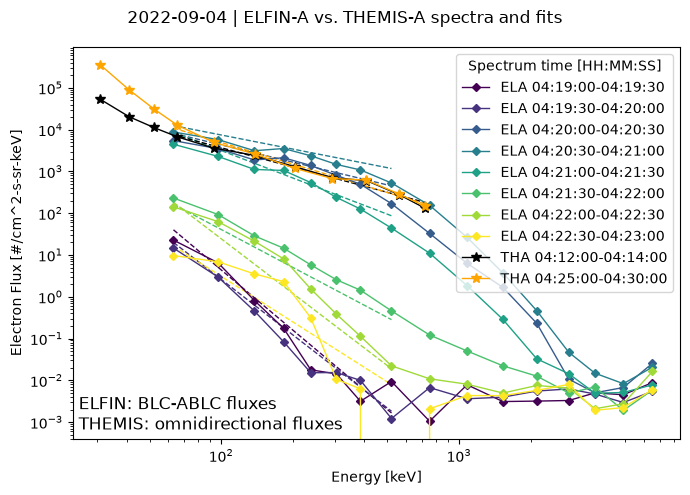

In [43]:
fig, fx = plt.subplots(1, 1, figsize=(7, 5))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(elfin_spectral_times)-1))
themis_colors = ['k', 'orange']
elfin_spectra_mean = np.nan*np.zeros((len(elfin_spectral_times)-1, pad_obj_nflux.energy.shape[0]))
elfin_spectra_iqr = np.nan*np.zeros((len(elfin_spectral_times)-1, 2, pad_obj_nflux.energy.shape[0]))

for i, (start_time, end_time, color) in enumerate(zip(elfin_spectral_times[:-1], elfin_spectral_times[1:], colors)):
    pad_flt = pad_obj_nflux.pad.sel(time=slice(start_time, end_time))
    elfin_spectra_mean[i, :] = pad_flt.mean(dim=('time', 'pa'), skipna=True).sel(energy=pad_obj_nflux._flux_keys)/1e3
    # yerr = np.abs(elfin_spectra_mean[i, :]-elfin_spectra_iqr[i, :]),
    # elfin_spectra_iqr[i, ...] = pad_flt.quantile((0.25, 0.75), dim=('time', 'pa'), skipna=True).sel(energy=pad_obj_nflux._flux_keys)
    fx.errorbar(pad_obj_nflux.energy, elfin_spectra_mean[i, :], color=color, yerr=None, capsize=2,
            markersize=4, elinewidth=1, marker='D', lw=1, 
            label=f'ELA {start_time:%H:%M:%S}-{end_time:%H:%M:%S}')

    gamma, j0 = elfin_fit_params.loc[i, ['gamma', 'J0 [#/cm^2-s-sr-keV]']]
    fx.plot(pad_obj_nflux.energy[elfin_fit_idx], j0*pad_obj_nflux.energy[elfin_fit_idx]**(-gamma), color=color, ls='--', lw=1)

    # e0, j0 = fit_elfin_spectrum(pad_obj, (start_time, end_time), energy_range=fit_energy_range, spectral_type='exp')
    # fx.plot(pad_obj_nflux.energy[elfin_fit_idx], j0*np.exp(-pad_obj_nflux.energy[elfin_fit_idx]/e0), color=color, ls='--', lw=1)

for i, (themis_time_range, color) in enumerate(zip(themis_a_spectra_time_ranges, themis_colors)):
    fx.errorbar(tha_sst_xr.v[0, valid_sst_channels]/1E3,  themis_spectra_mean[i, :], color=color, yerr=None, capsize=2,
            markersize=7, elinewidth=1, marker='*', lw=1,
            label=f'THA {themis_time_range[0]:%H:%M:%S}-{themis_time_range[1]:%H:%M:%S}')
    gamma, j0 = themis_fit_params.loc[i, ['gamma', 'J0 [#/cm^2-s-sr-keV]']]
    fx.plot(integrate_energies_kev, j0*integrate_energies_kev**(-gamma), color=color, ls='--', lw=1)

fx.set(xlabel='Energy [keV]', yscale='log', xscale='log')
fx.legend(loc='upper right', title='Spectrum time [HH:MM:SS]', fontsize=10, title_fontsize=10)
fx.set_ylabel(f'Electron Flux [#/cm^2-s-sr-keV]')
fx.text(0.01, 0.01, f'ELFIN: BLC-ABLC fluxes\nTHEMIS: omnidirectional fluxes', transform=fx.transAxes, va='bottom', fontsize=12)
plt.suptitle(f'{elfin_spectral_times[0]:%Y-%m-%d} | ELFIN-A vs. THEMIS-A spectra and fits');
plt.tight_layout()
plt.savefig(elfinasi.plot_dir / f'{elfin_spectral_times[0]:%Y%m%d_%H%M}_elfina_themisa_spectra_and_fits.pdf')

Looks like the THEMIS-A and ELFIN-A spectra agree really well between 04:20:15-04:21:15 which corresponds to the outer RB and the IB. So this means that the trapped fluxes were isotropic over a few L-shells (unknwon due to mapping, but it corresponds to about 90 seconds of ELFIN).

## RB loss estimate

Let's now estimate how many electrons were lost to both hemispheres during this time. Thanks to Google Gemini, here is how we'll calculate it.

$$N_{trapped} = \int_{V} \int_{E} \int_{\Omega} \underbrace{\left( \frac{j(E, \Omega)}{v(E)} \right)}_{\left[\frac{\text{particles}}{\text{cm}^3 \cdot \text{sr} \cdot \text{keV}}\right]} \underbrace{d\Omega}_{[\text{sr}]} \, \underbrace{dE}_{[\text{keV}]} \, \underbrace{dV}_{[\text{cm}^3]} \quad \longrightarrow \quad \text{Total Particles}$$

where 

$$v(E) = c \sqrt{1 - \left( \frac{E_0}{E + E_0} \right)^2}$$

is the relativistic velocity, and we integrate the number of trapped particles contained in the flux tube volume

$$V_{sector} = (B_{iono} \cdot A_{iono}) \int_{s_{S}}^{s_{N}} \frac{1}{B(s)} \, ds$$

You can inteutively think this from the conservation of magnetic flux (and because $\rho_e \sim B$). The $\cdot A_{iono}$ is the ionsophereic flux tube foorptint area which we reference to $B_{iono}$. Since the the flux tube footprint area decreases with $B$ (gyroradius gets smaller), it conversely gets larger with smaller $B$. Therefore, as we trace the field line to the magnetic equator and then to the conjugate footprint, the small area contributions scale with $1/B$. 

Now the rate of particles lost is 

$$\frac{N_{lost}}{dt} = 4 \cdot \pi \cdot A_{iono} \cdot \int_{E_{min}}^{E_{max}} \int_{\alpha=0}^{\alpha_{LC}} j_{ELFIN}(E) \, \sin{\alpha} \cos{\alpha} \ d\alpha \ dE$$

where $j_{ELFIN}(E)$ is the ELFIN flux with units $\mathrm{\# /(cm^2 \ sr \ s \ keV)}$, one factor of 2 accounts for losses in both hemispheres, and $2\pi \ [sr]$ assumes gyrotropy. This assumes that the precipitation is isotropic $0 < \alpha < \alpha_{LC}$.

Putting this all together, the fraction lost every second is

$$f = \frac{\frac{N_{lost}}{dt}}{N_{trapped}}$$

and the number of seconds to completely empty the loss cone is

$$\tau = \frac{N_{trapped}}{\frac{N_{lost}}{dt}}$$

Let's first calculate the precipitation area and the flux tube volume

In [44]:
themis_location_codes = ['GILL', 'ATHA', 'PINA', 'TPAS', 'KAPU']
asis = asilib.Imagers([
    asilib.asi.themis(loc, time='2022-09-04T04:21:24', alt=110) for loc in themis_location_codes
    ])

In [45]:
area_vertices = [
    (-115, 55), (-82, 57), (-78, 51), (-100, 51)
]
central_lonlat = np.mean(area_vertices, axis=0)
central_lonlat

array([-93.75,  53.5 ])

In [46]:
poly_lonlat = shapely.geometry.Polygon(area_vertices)
src_crs = ccrs.PlateCarree()
tgt_crs = ccrs.AlbersEqualArea(
    central_longitude=central_lonlat[0], 
    central_latitude=central_lonlat[1]
    )

# 3. Transform the geometry coordinates to the target projection
poly_projected = tgt_crs.project_geometry(poly_lonlat, src_crs)

# 4. Extract the area (returned in square meters)
area_sq_meters = poly_projected.area
area_sq_cm = area_sq_meters * 1e4
area_sq_km = area_sq_meters / 1e6
print(f'Lower-bound area of the expansion phase aurora is {area_sq_km=:.2e} [km^2]')

Lower-bound area of the expansion phase aurora is area_sq_km=1.15e+06 [km^2]


Now let's visualize the precipitation area

11-Sep-26 11:27:04: /home/msshumko/research/.venv/lib/python3.13/site-packages/cartopy/mpl/ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)

11-Sep-26 11:27:04: /home/msshumko/research/.venv/lib/python3.13/site-packages/cartopy/mpl/ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)

11-Sep-26 11:27:06: /home/msshumko/research/.venv/lib/python3.13/site-packages/cartopy/mpl/ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs, degs, mins, secs = self._get_dms(self.locs)

11-Sep-26 11:27:06: /home/msshumko/research/.venv/lib/python3.13/site-packages/cartopy/mpl/ticker.py:151: MatplotlibDeprecationWarning: The locs attribute was deprecated in

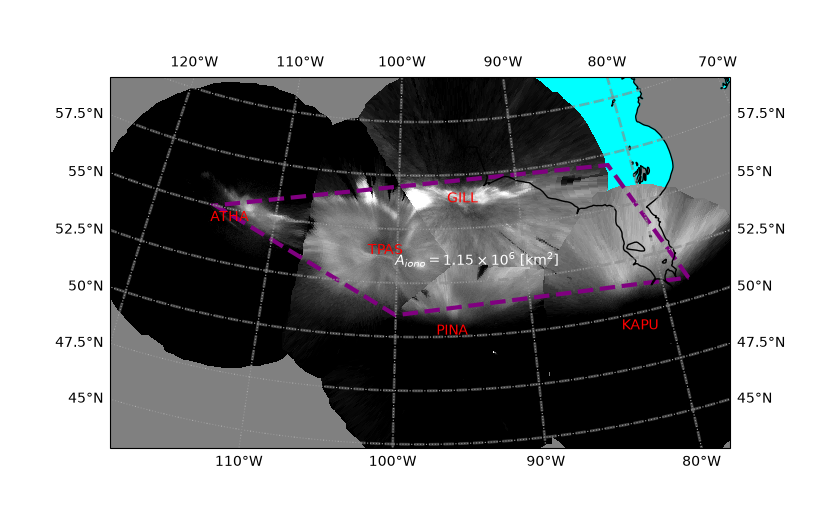

In [47]:
center = (
    np.mean(asis.lon_bounds), np.mean(asis.lat_bounds)
)
projection = ccrs.Orthographic(
    central_longitude=center[0], 
    central_latitude=center[1]
)
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection=projection)
ax.add_feature(cfeature.LAND, color='grey')
ax.add_feature(cfeature.OCEAN, color='cyan')
ax.add_feature(cfeature.COASTLINE, edgecolor='k')
ax.gridlines(linestyle=':')
ax.set_global()
ax.set_extent(
    (center[0]-20, center[0]+20, center[1]-10, center[1]+8), 
    crs=ccrs.PlateCarree()
    )

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True,
    linewidth=2, color='gray', alpha=0.5, linestyle='--'
    )

asis.plot_map(ax=ax, color_bounds=asis.imagers[0].auto_color_bounds())

shape = matplotlib.patches.Polygon(
    area_vertices, closed=True, facecolor='None', edgecolor='purple', lw=3, ls='--',
    transform=ccrs.Geodetic()
    )
ax.add_patch(shape)
base, exp = f"{area_sq_km:.2e}".split("e")
ax.text(
    central_lonlat[0], 
    central_lonlat[1], 
    f'$A_{{iono}} = {base} \\times 10^{{{int(exp)}}} \\ [\\mathrm{{km^2}}]$', 
    color='white', 
    fontsize=10, 
    fontweight='bold',
    transform=ccrs.Geodetic(), 
    ha='center', 
    va='center'
    );

In [48]:
def flux_tube_volume(irbem_model, X, maginput, starting_area, R0=1, interpNum=100_000):
    """
    Calculate the volume of a flux tube volume of a magnetic field line, scaled to the 
    starting area (typically taken in the ionosphere).
    
    Parameters
    ----------
    irbem_model: IRBEM.MagFields
        An instance of the IRBEM.MagFields class, which is used to compute magnetic field lines.
    X: dict
        A dictionary that specifies the input time and location. The `time` key can be a
        ISO-formatted time string, or a `datetime.datetime` or `pd.TimeStamp` objects. 
        The three location keys: `x1`, `x2`, and `x3` specify the location in the `sysaxes`.
    maginput: dict
        The magnetic field input dictionary. See the online documentation for the valid
        keys and the corresponding models.
    starting_area: float
        The cross-sectional area of the flux tube at the starting point, with cm^2 units.
    R0: float
        The radius, in units of RE, of the reference surface (i.e. altitude) between which 
        the line is traced.
    interpNum: int
        The number of samples to interpolate the magnetic field line.
        100000 is a good balance between speed and accuracy.

    Returns
    -------
    float
        Flux tube volume(s) in cubic cm.
    """    
    field_line_dict = irbem_model._interpolate_field_line(X, maginput, R0=R0, alpha=90)
                                            
    # If the mirror point is below the ground, Scipy will error, try 
    # to change the R0 parameter...
    try:
        startInd = scipy.optimize.brentq(field_line_dict['fB'], 0, 
                                            len(field_line_dict['S'])/2)
        endInd = scipy.optimize.brentq(field_line_dict['fB'], 
                                    len(field_line_dict['S'])/2, len(field_line_dict['S'])-1)
    except ValueError as err:
        if str(err) == 'f(a) and f(b) must have different signs':
                raise ValueError('Mirror point below R0') from err
        else:
            raise
    
    # Resample S to a finer density of points.
    if len(field_line_dict['S']) > interpNum: 
        warnings.warn('Warning: interpolating with less data than IRBEM outputs,'+
        ' the bounce period may be inaccurate!')
    sInterp = np.linspace(startInd, endInd, num = interpNum)
    
    # Calculate the small change in position, and magnetic field.
    dx = np.convolve(field_line_dict['fx'](sInterp), [-1,1], mode = 'same')
    dy = np.convolve(field_line_dict['fy'](sInterp), [-1,1], mode = 'same')
    dz = np.convolve(field_line_dict['fz'](sInterp), [-1,1], mode = 'same')
    ds = R_E*1e5*np.sqrt(dx**2 + dy**2 + dz**2)
    dB = field_line_dict['fB'](sInterp) + field_line_dict['mirrorB']    
    starting_flux = starting_area*field_line_dict['mirrorB']
    V = starting_flux*np.trapezoid(1/dB, dx=ds[1:])
    return V

In [49]:
mag_model = IRBEM.MagFields(kext='T89')

In [50]:
tube_V = flux_tube_volume(
    mag_model,
    {'time':elfin_spectral_times[0], 'x1':100, 'x2':central_lonlat[1], 'x3':central_lonlat[0]},
    {'Kp':50},
    starting_area=area_sq_cm
    )
print(f'Flux tube volume at {elfin_spectral_times[0]} is {tube_V:.2e} cm^3.')

Flux tube volume at 2022-09-04 04:19:00 is 3.05e+28 cm^3.


Sanity check. How many cubic Re fit into the flux tube?

In [51]:
R_E_cm = R_E*1e5
int(tube_V/R_E_cm**3)

117

Okay! 117 Cubic Earth's appears approproate. How many trapped electrons were there?

In [52]:
_gamma_themis, _j0_themis = themis_fit_params.loc[1, ['gamma', 'J0 [#/cm^2-s-sr-keV]']]  # Doesn't matter much if i=0 or 1.

v = SPEED_OF_LIGHT*np.sqrt(
    1-(ELECTRON_REST_ENERGY/(ELECTRON_REST_ENERGY+integrate_energies_kev))**2
    )  # cm/s
# 1e6 is to convert from eV to MeV, 4pi is to account for the solid angle of the trapped electrons.
N_trapped = 4*np.pi*tube_V*np.trapezoid(
    y=_j0_themis*integrate_energies_kev**(-_gamma_themis)/v,
    x=integrate_energies_kev
)
print(
    f'Number of trapped electrons between {integrate_energies_kev[0]} keV and {integrate_energies_kev[-1]} keV is {N_trapped:.1e} electrons.'
    )

Number of trapped electrons between 63.0 keV and 719.5 keV is 1.7e+25 electrons.


$1.7 \times 10^{25}$ trapped electrons seem to be appropriate to previous studies

1. [Millan+2002](https://doi.org/10.1029/2002GL015922),
2. [Blum+2013](https://doi.org/10.1002%2F2013GL058546)
3. [O'Brien+2004](https://doi.org/10.1029/2003GL018621)
4. [Lorentzen+2001](https://doi.org/10.1029/2001GL012926)

**Need to find more recent studies**.

Now let us calculatate the loss rate

In [53]:
loss_spectrum_time = pd.to_datetime("2022-09-04T04:20:00")

# 2. Compute absolute time delta and locate the minimum
closest_row_index = (elfin_fit_params["start_time"] - loss_spectrum_time).abs().idxmin()
_j0_elfin, _gamma_elfin = elfin_fit_params.loc[closest_row_index, ['J0 [#/cm^2-s-sr-keV]', 'gamma']]

lc_integral = np.sin(np.deg2rad(pad_obj_nflux.lc.angle.mean()))**2/2

# 2*np.pi corresponds to gyrotropic precipitation, and the additional 2 corresponds to the two hemispheres.
dN_lost_dt = 4*np.pi*lc_integral*area_sq_cm*np.trapezoid(
    y=_j0_elfin*(integrate_energies_kev)**(-_gamma_elfin),
    x=integrate_energies_kev
)
print(
    f'Number of electrons lost per second in {integrate_energies_kev[0]}-{integrate_energies_kev[-1]} keV '
    f'is: {dN_lost_dt:.1e} e-/s. The number of time to lose the trapped population is: {N_trapped/dN_lost_dt/60:.1f} minutes.'
    )

Number of electrons lost per second in 63.0-719.5 keV is: 5.4e+22 e-/s. The number of time to lose the trapped population is: 5.1 minutes.


1 minute assuming a dipole volume and ~5 minutes assuming a T89 volume both seem fast! On the order of how long the expansion phase lasts. The dipole one seems to be unphysically quick, but the T89 one looks ok.